# 🏆 Prédiction des Résultats de Ligue 1 — Saison 2025-2026

---

## 1. Introduction

### Présentation du problème

Le football est l'un des sports les plus imprévisibles au monde. Pourtant, à travers l'analyse de données historiques, il est possible d'identifier des **patterns statistiques** permettant de mieux anticiper les résultats des matchs.

Ce projet académique s'inscrit dans le cadre de la **prédiction multi-classes** : pour chaque match de la saison 2025-2026 de Ligue 1, nous cherchons à prédire :

| Classe | Signification |
|--------|---------------|
| `1`    | Victoire de l'équipe à **domicile** |
| `0`    | **Match nul** |
| `-1`   | Victoire de l'équipe à **l'extérieur** |

### Objectif

Construire un **classifieur performant** en s'appuyant sur des données historiques enrichies et 6 axes d'amélioration avancés :

| # | Amélioration | Justification |
|---|---|---|
| 1 | **Proxies xG** (type de tir, pénaltys, têtes, timing) | Extraits des `game_events` — approche Opta/Statsbomb |
| 2 | **LSTM** double-branche | Capture les patterns temporels et le momentum |
| 3 | **Absence joueurs clés** | Inférée depuis `game_lineups` × impact scores |
| 4 | **Calibration probabiliste** | Probabilités fiables (isotonic regression) |
| 5 | **Ensemble learning** (soft voting + stacking) | Réduction de variance, complémentarité des modèles |
| 6 | **H2H pondéré** (décroissance exponentielle) | Matchs récents plus informatifs que les anciens |

### Description des données

| Fichier | Contenu | Lignes |
|---------|---------|--------|
| `matchs_2013_2024.csv` | Historique des matchs avec résultats | ~4 691 |
| `match_2025.csv` | Matchs à prédire (saison 2025-2026) | 233 |
| `clubs_fr.csv` | Statistiques des clubs (effectif, transferts…) | 36 |
| `player_appearance.csv` | Statistiques individuelles par match | ~128 240 |
| `player_valuation_before_season.csv` | Valeur marchande des joueurs | ~32 856 |
| `game_events_before2025.csv` | Événements détaillés des matchs | ~61 944 |
| `game_lineups.csv` | Compositions d'équipes | ~161 049 |
| `sample_results.csv` | Format de sortie attendu | 233 |

---
## 2. Chargement des Données

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, log_loss
)

# Boosting
from xgboost import XGBClassifier
import lightgbm as lgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Input, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from matplotlib.patches import Patch

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Librairies importées')
print(f'   TensorFlow : {tf.__version__} | LightGBM : {lgb.__version__}')

✅ Librairies importées
   TensorFlow : 2.21.0 | LightGBM : 4.6.0


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CHARGEMENT DES FICHIERS CSV
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = 'data/'   # ← Adapter si nécessaire

matches     = pd.read_csv(DATA_PATH + 'matchs_2013_2024.csv')
m2025       = pd.read_csv(DATA_PATH + 'match_2025.csv')
clubs       = pd.read_csv(DATA_PATH + 'clubs_fr.csv')
valuation   = pd.read_csv(DATA_PATH + 'player_valuation_before_season.csv')
events      = pd.read_csv(DATA_PATH + 'game_events_before2025.csv')
lineups     = pd.read_csv(DATA_PATH + 'game_lineups.csv', low_memory=False)
appearances = pd.read_csv(DATA_PATH + 'player_appearance.csv')
sample      = pd.read_csv(DATA_PATH + 'sample_results.csv')

# Conversions de types
for df in [matches, m2025, appearances]:
    df['date'] = pd.to_datetime(df['date'])
valuation['date'] = pd.to_datetime(valuation['date'])
events['date']    = pd.to_datetime(events['date'])

print('📦 Fichiers chargés :')
for name, df in [('matches', matches), ('m2025', m2025), ('clubs', clubs),
                 ('valuation', valuation), ('events', events),
                 ('lineups', lineups), ('appearances', appearances)]:
    print(f'  {name:>14s} : {df.shape[0]:>7,} lignes × {df.shape[1]} colonnes')

📦 Fichiers chargés :
         matches :   4,691 lignes × 23 colonnes
           m2025 :     233 lignes × 12 colonnes
           clubs :      36 lignes × 13 colonnes
       valuation :  32,856 lignes × 6 colonnes
          events :  61,944 lignes × 12 colonnes
         lineups : 161,049 lignes × 11 colonnes
     appearances : 128,240 lignes × 13 colonnes


In [3]:
# Aperçu des datasets principaux
print('=== matchs_2013_2024 ===')
display(matches.head(3))
print('\n=== match_2025 ===')
display(m2025.head(3))
print('\n=== game_events ===')
display(events.head(3))
print('\n=== player_appearance ===')
display(appearances.head(3))

=== matchs_2013_2024 ===


,Unnamed: 0,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type,results
0,523,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,...,Stade Francis-Le Blé,10627.0,Sébastien Moreira,NaN,NaN,Stade brestois 29,Valenciennes FC,2:1,domestic_league,1
1,524,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,...,Stade François-Coty,6029.0,Olivier Thual,NaN,NaN,AC Ajaccio,Stade brestois 29,1:0,domestic_league,1
2,525,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,...,Stade Auguste-Delaune,13413.0,Jean-Charles Cailleux,NaN,NaN,Stade Reims,AS Nancy-Lorraine,2:0,domestic_league,1



=== match_2025 ===


,game_id,date,home_club_id,away_club_id,home_club_manager_name,away_club_manager_name,stadium,attendance,referee,home_club_name,away_club_name,competition_type
0,4635006,2025-08-15,273,244,Habib Beye,Roberto De Zerbi,Roazhon Park,28360.0,Jérémie Pignard,Stade Rennais Football Club,Olympique de Marseille,domestic_league
1,4635007,2025-08-16,826,1041,Pierre Sage,Paulo Fonseca,Stade Bollaert-Delelis,38137.0,Romain Lissorgue,Racing Club de Lens,Olympique Lyonnais,domestic_league
2,4635008,2025-08-16,417,415,Franck Haise,Carles Martínez,Allianz Riviera,23212.0,Thomas Léonard,Olympique Gymnaste Club Nice Côte d'Azur,Toulouse Football Club,domestic_league



=== game_events ===


,Unnamed: 0,game_event_id,date,game_id,minute,type,club_id,club_name,player_id,description,player_in_id,player_assist_id
0,6816,5d2b67957aaae6cf2a41e70cb5d4024f,2012-09-22,2223841,73,Substitutions,3911,Stade Brestois 29,5399,", Not reported",37516.0,NaN
1,6817,cd511880b945623db06ace57349e45b2,2012-09-22,2223841,76,Goals,3911,Stade Brestois 29,24459,", Penalty, 2. Goal of the Season Assist: , Fou...",NaN,24459.0
2,6818,8ca118538b45a24643ab1c9f76e50f6d,2012-09-22,2223841,56,Substitutions,3911,Stade Brestois 29,25113,", Not reported",22053.0,NaN



=== player_appearance ===


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2229837_108830,2229837,108830,415,3205,2012-08-10,Aymen Abdennour,FR1,1,0,0,0,90
1,2229837_113707,2229837,113707,969,1082,2012-08-10,Rémy Cabella,FR1,1,0,0,0,42
2,2229837_126767,2229837,126767,415,3205,2012-08-10,Ali Ahamada,FR1,0,0,0,0,90


---
## 3. Exploration des Données (EDA)

L'analyse exploratoire est une étape fondamentale. Elle nous permet de :
- Comprendre la **structure et la qualité** des données
- Identifier les **valeurs manquantes** et aberrantes
- Découvrir des **relations statistiques** utiles pour la modélisation
- Formuler des **hypothèses** sur les features les plus discriminantes

### 3.1 Distribution de la variable cible

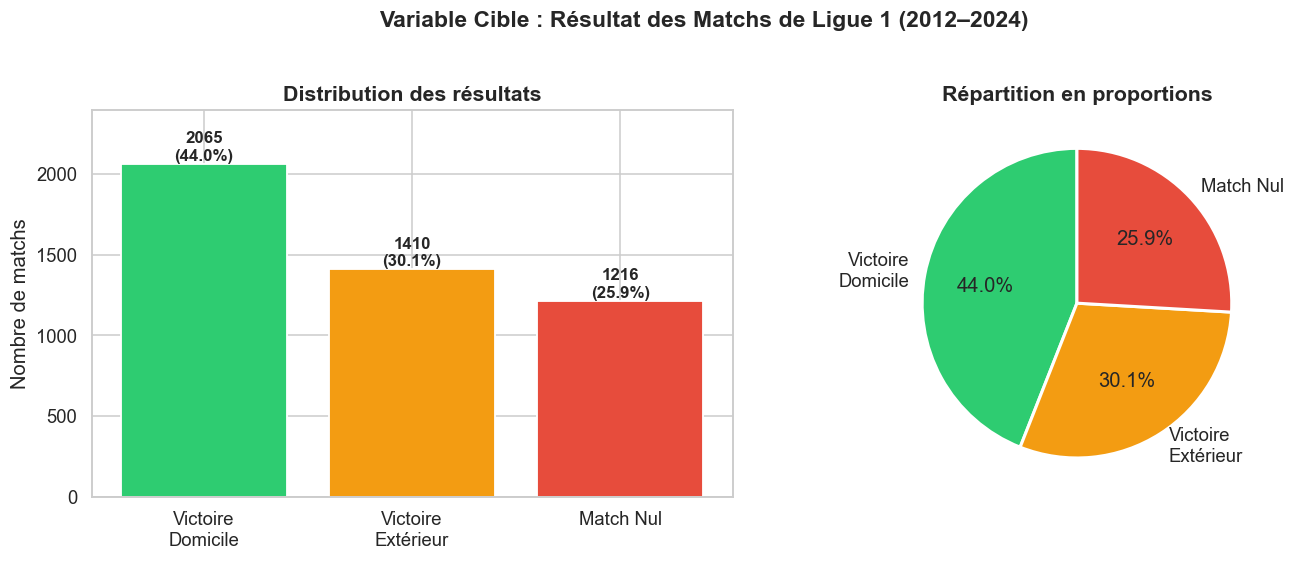

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_map = {1: 'Victoire\nDomicile', 0: 'Match Nul', -1: 'Victoire\nExtérieur'}
counts = matches['results'].map(label_map).value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, (lab, val) in enumerate(counts.items()):
    axes[0].text(i, val + 20, f'{val}\n({val/len(matches)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribution des résultats', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de matchs')
axes[0].set_ylim(0, 2400)

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Répartition en proportions', fontsize=14, fontweight='bold')

plt.suptitle('Variable Cible : Résultat des Matchs de Ligue 1 (2012–2024)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**💡 Insight :** La variable cible est **déséquilibrée** : les victoires à domicile représentent ~44% des matchs. Un modèle « naïf » qui prédit toujours la victoire à domicile atteindrait ~44% d'accuracy — c'est notre **baseline** à dépasser. Cet avantage du terrain est un phénomène bien documenté en football.

### 3.2 Évolution des résultats par saison

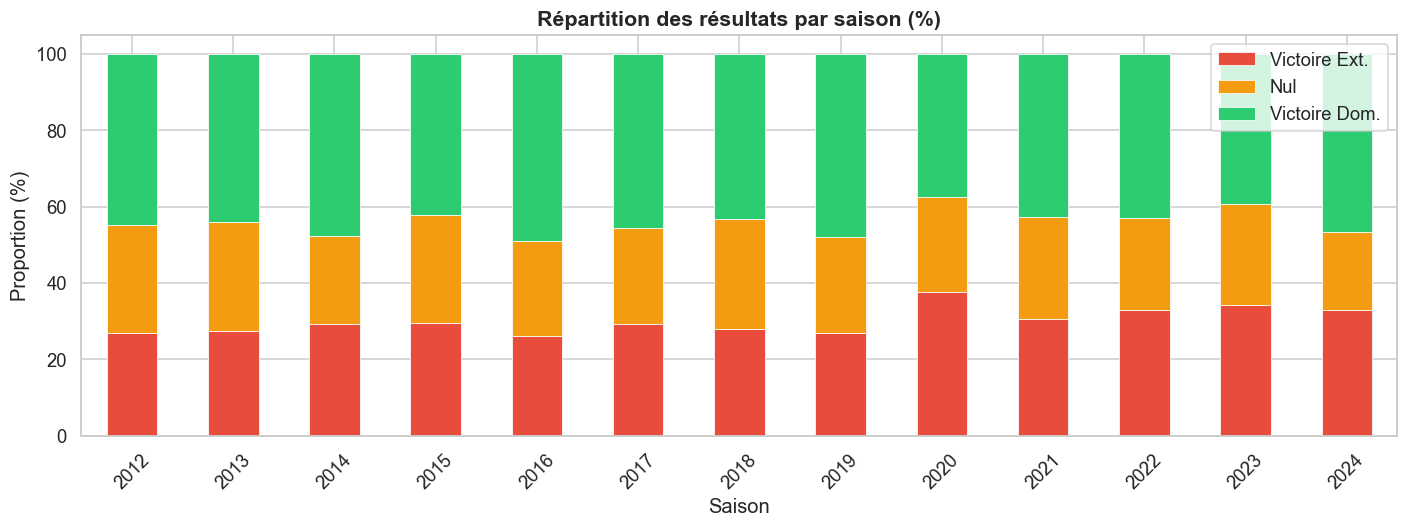

In [5]:
season_results = matches.groupby(['season', 'results']).size().unstack(fill_value=0)
season_results.columns = ['Victoire Ext.', 'Nul', 'Victoire Dom.']
season_pct = season_results.div(season_results.sum(axis=1), axis=0) * 100

ax = season_pct.plot(kind='bar', stacked=True, figsize=(13, 5),
                     color=['#e74c3c', '#f39c12', '#2ecc71'],
                     edgecolor='white', linewidth=0.5)
ax.set_title('Répartition des résultats par saison (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Saison')
ax.set_ylabel('Proportion (%)')
ax.legend(loc='upper right')
ax.set_xticklabels(season_pct.index, rotation=45)
plt.tight_layout()
plt.show()

**💡 Insight :** La répartition est **relativement stable** au fil des saisons, avec une légère hausse des victoires extérieures sur les dernières années — possible reflet de l'évolution tactique du football moderne (pressing haut, jeu de possession des équipes visiteuses).

### 3.3 Analyse des buts

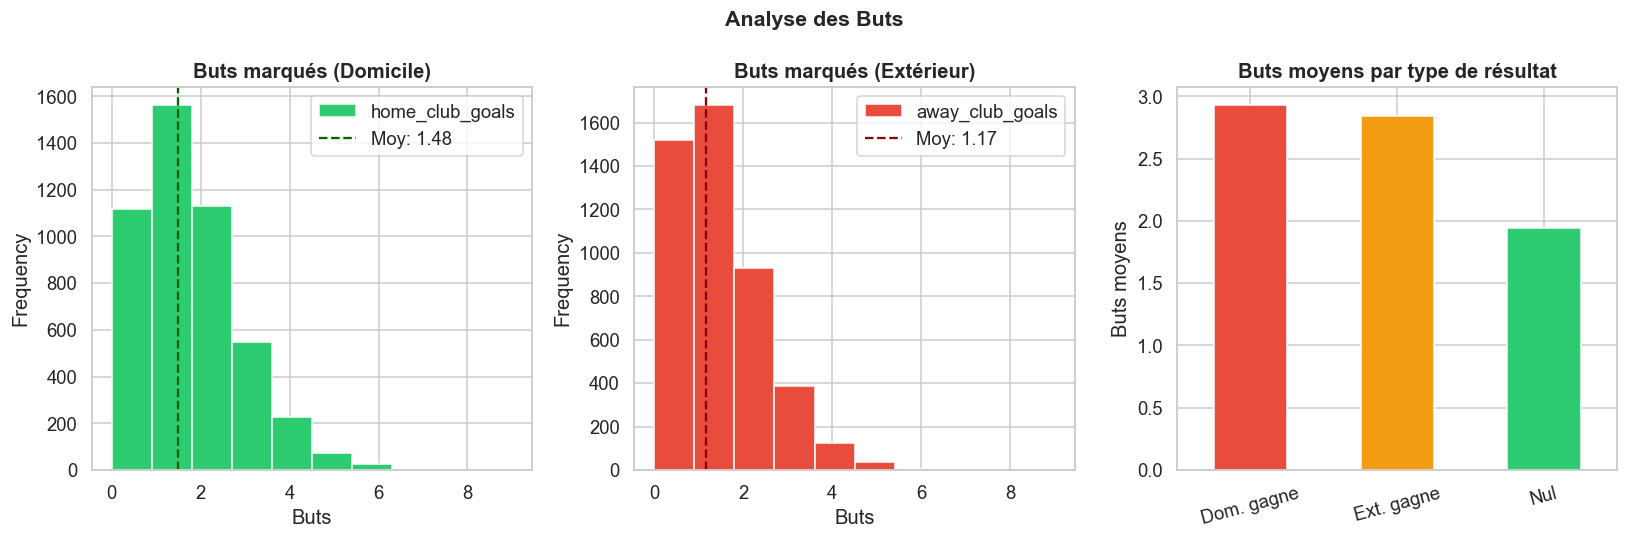

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

matches['home_club_goals'].plot(kind='hist', bins=10, ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('Buts marqués (Domicile)', fontweight='bold')
axes[0].set_xlabel('Buts')
axes[0].axvline(matches['home_club_goals'].mean(), color='darkgreen', linestyle='--',
                label=f"Moy: {matches['home_club_goals'].mean():.2f}")
axes[0].legend()

matches['away_club_goals'].plot(kind='hist', bins=10, ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Buts marqués (Extérieur)', fontweight='bold')
axes[1].set_xlabel('Buts')
axes[1].axvline(matches['away_club_goals'].mean(), color='darkred', linestyle='--',
                label=f"Moy: {matches['away_club_goals'].mean():.2f}")
axes[1].legend()

matches['total_goals'] = matches['home_club_goals'] + matches['away_club_goals']
matches['result_label'] = matches['results'].map({1:'Dom. gagne', 0:'Nul', -1:'Ext. gagne'})
matches.groupby('result_label')['total_goals'].mean().plot(
    kind='bar', ax=axes[2], color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
axes[2].set_title('Buts moyens par type de résultat', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Buts moyens')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Analyse des Buts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight :** Les équipes à domicile marquent en moyenne **~1.48 buts** contre **~1.07** pour les équipes extérieures. Les matchs nuls comportent moins de buts en moyenne, souvent terminés 0-0 ou 1-1.

### 3.4 Analyse des positions au classement

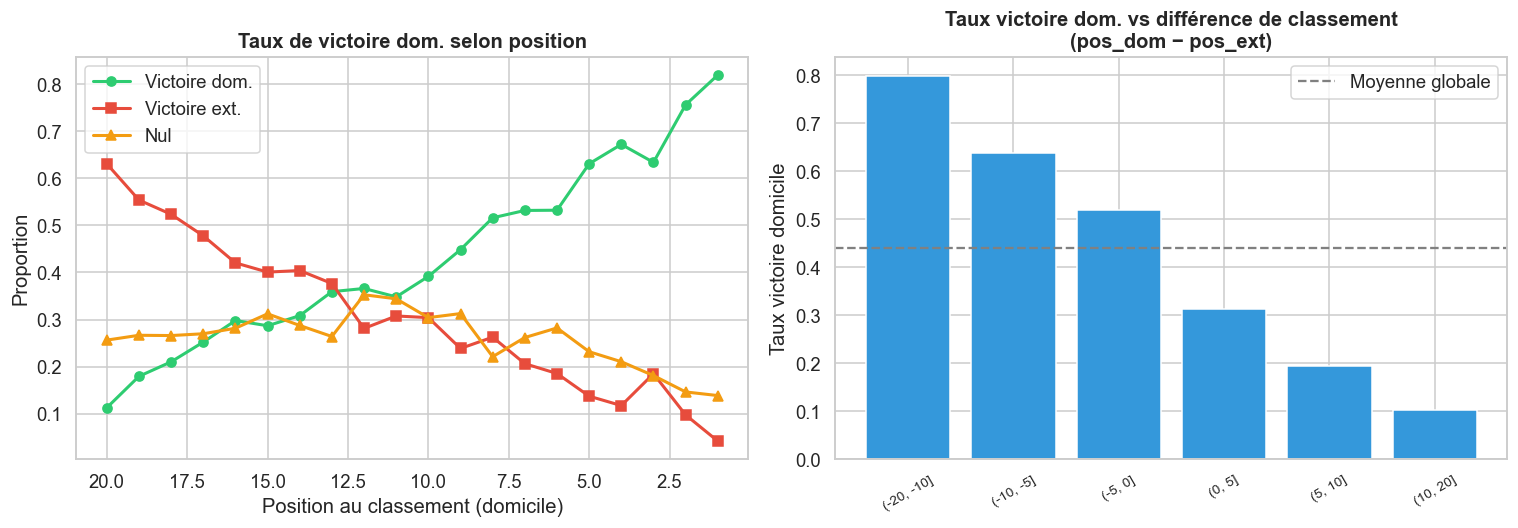

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_result = matches.groupby(['home_club_position','results']).size().unstack(fill_value=0)
pos_result_pct = pos_result.div(pos_result.sum(axis=1), axis=0)
if 1 in pos_result_pct.columns:
    axes[0].plot(pos_result_pct.index, pos_result_pct[1], 'o-', color='#2ecc71', label='Victoire dom.', linewidth=2)
if -1 in pos_result_pct.columns:
    axes[0].plot(pos_result_pct.index, pos_result_pct[-1], 's-', color='#e74c3c', label='Victoire ext.', linewidth=2)
if 0 in pos_result_pct.columns:
    axes[0].plot(pos_result_pct.index, pos_result_pct[0], '^-', color='#f39c12', label='Nul', linewidth=2)
axes[0].set_title('Taux de victoire dom. selon position', fontweight='bold')
axes[0].set_xlabel('Position au classement (domicile)')
axes[0].set_ylabel('Proportion')
axes[0].legend()
axes[0].invert_xaxis()

matches['pos_diff'] = matches['home_club_position'] - matches['away_club_position']
pos_diff_bins = pd.cut(matches['pos_diff'], bins=[-20,-10,-5,0,5,10,20])
win_rate = matches.groupby(pos_diff_bins)['results'].apply(lambda x: (x==1).mean()).reset_index()
win_rate.columns = ['pos_diff_bin','win_rate_home']
win_rate['pos_diff_bin'] = win_rate['pos_diff_bin'].astype(str)
axes[1].bar(range(len(win_rate)), win_rate['win_rate_home'], color='#3498db', edgecolor='white')
axes[1].set_xticks(range(len(win_rate)))
axes[1].set_xticklabels(win_rate['pos_diff_bin'], rotation=30, fontsize=9)
axes[1].set_title('Taux victoire dom. vs différence de classement\n(pos_dom − pos_ext)', fontweight='bold')
axes[1].set_ylabel('Taux victoire domicile')
axes[1].axhline(0.44, linestyle='--', color='gray', label='Moyenne globale')
axes[1].legend()
plt.tight_layout()
plt.show()

**💡 Insight :** La position au classement est **très discriminante** : les équipes mieux classées gagnent nettement plus souvent. La différence de position est une feature clé pour le modèle.

### 3.5 Valeurs manquantes

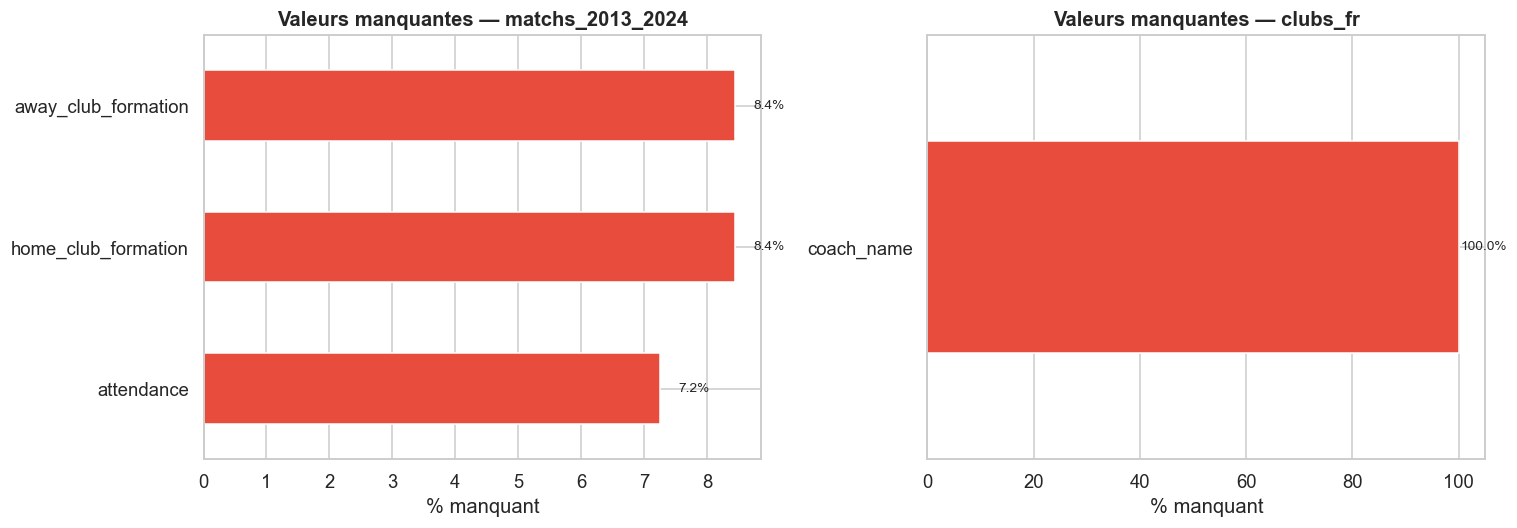


Résumé (matches) :


,nb_manquants
attendance,340
home_club_formation,396
away_club_formation,396


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, df) in zip(axes, [('matchs_2013_2024', matches), ('clubs_fr', clubs)]):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0].sort_values(ascending=True)
    if len(null_pct) == 0:
        ax.text(0.5, 0.5, 'Aucune valeur manquante ✅', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
    else:
        null_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
        for i, v in enumerate(null_pct.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Valeurs manquantes — {name}', fontweight='bold')
    ax.set_xlabel('% manquant')
plt.tight_layout()
plt.show()
print('\nRésumé (matches) :')
display(matches.isnull().sum()[matches.isnull().sum()>0].to_frame('nb_manquants'))

**💡 Insight :** Valeurs manquantes concentrées sur `home/away_club_formation` (~8%) et `attendance` (~7%). Elles seront gérées par imputation médiane.

### 3.6 Statistiques joueurs (appearances)

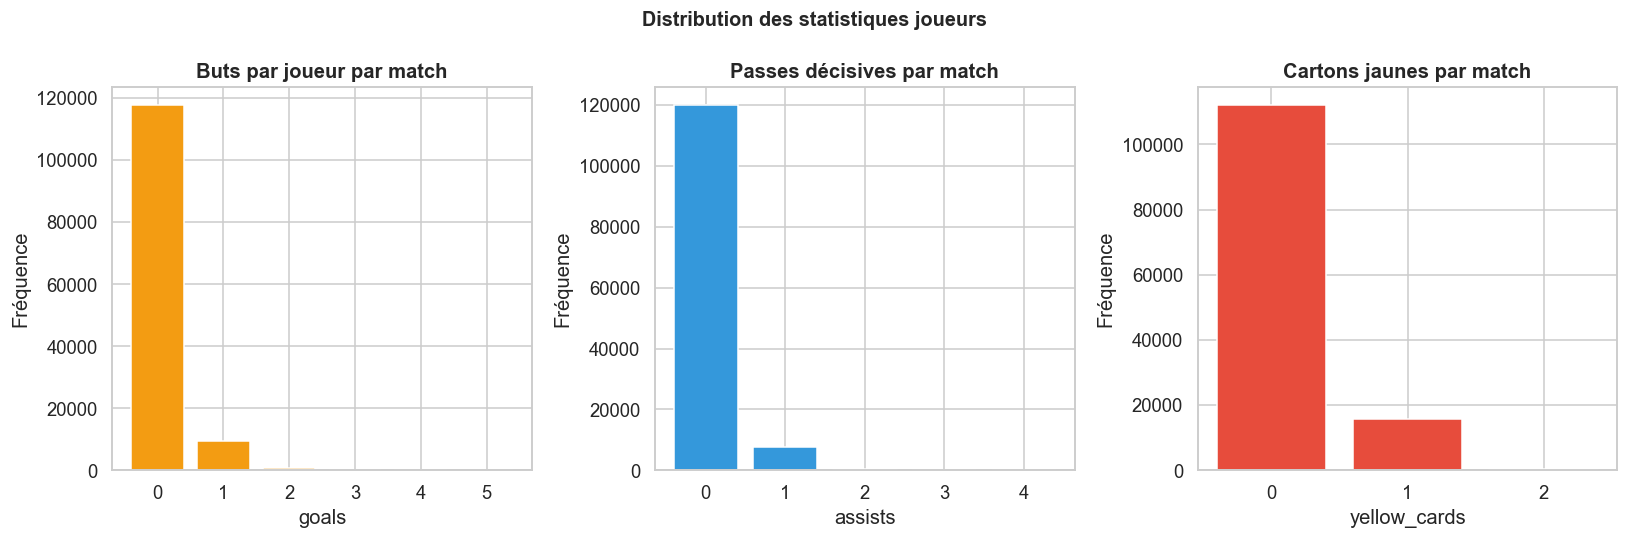

Statistiques descriptives :


,goals,assists,yellow_cards,red_cards,minutes_played
count,128240.000,128240.000,128240.000,128240.000,128240.000
mean,0.090,0.068,0.128,0.006,68.961
std,0.318,0.268,0.343,0.076,30.015
min,0.000,0.000,0.000,0.000,1.000
25%,0.000,0.000,0.000,0.000,51.000
50%,0.000,0.000,0.000,0.000,90.000
75%,0.000,0.000,0.000,0.000,90.000
max,5.000,4.000,2.000,1.000,90.000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color, title in zip(axes,
    ['goals','assists','yellow_cards'],
    ['#f39c12','#3498db','#e74c3c'],
    ['Buts par joueur par match','Passes décisives par match','Cartons jaunes par match']):
    val = appearances[col].value_counts().head(6)
    ax.bar(val.index.astype(str), val.values, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
plt.suptitle('Distribution des statistiques joueurs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Statistiques descriptives :')
display(appearances[['goals','assists','yellow_cards','red_cards','minutes_played']].describe().round(3))

### 3.7 Valeur marchande des joueurs

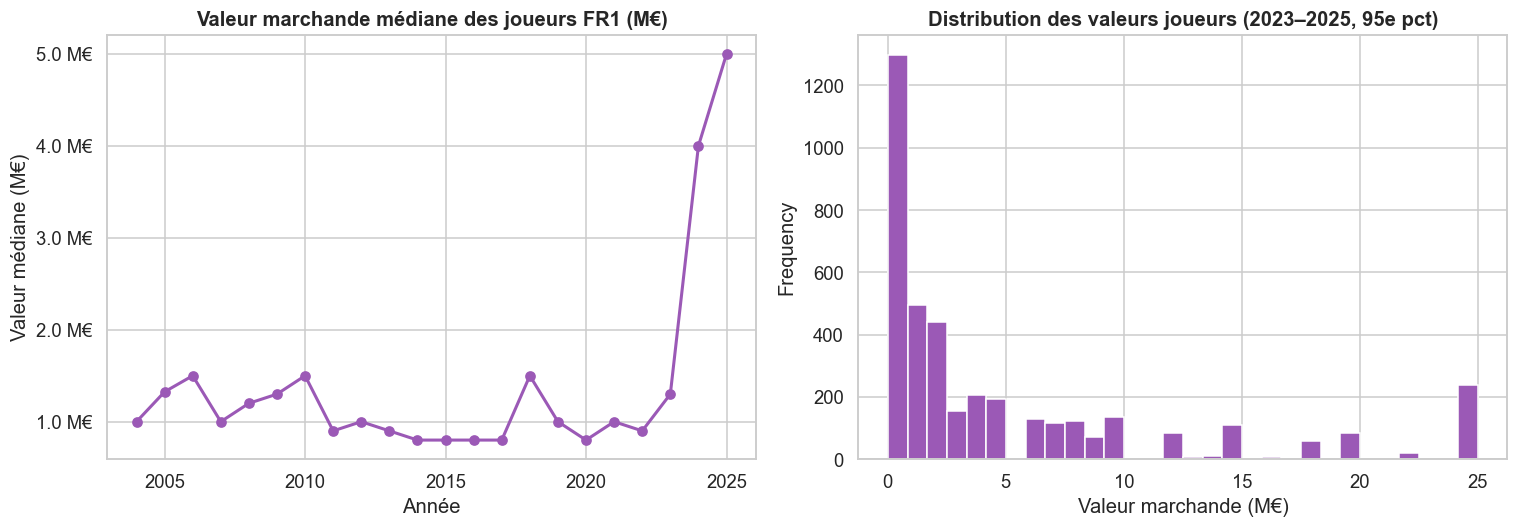

In [10]:
valuation['year'] = valuation['date'].dt.year
val_per_year = valuation.groupby('year')['market_value_in_eur'].median() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
val_per_year.plot(ax=axes[0], marker='o', color='#9b59b6', linewidth=2)
axes[0].set_title('Valeur marchande médiane des joueurs FR1 (M€)', fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Valeur médiane (M€)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f M€'))

recent_val = valuation[valuation['year'] >= 2023]['market_value_in_eur'] / 1e6
recent_val.clip(upper=recent_val.quantile(0.95)).plot(
    kind='hist', bins=30, ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Distribution des valeurs joueurs (2023–2025, 95e pct)', fontweight='bold')
axes[1].set_xlabel('Valeur marchande (M€)')
plt.tight_layout()
plt.show()

**💡 Insight :** La valeur marchande a **fortement augmenté** depuis 2013. Agréger la valeur totale de l'effectif par club sera une feature pertinente pour mesurer l'écart de niveau entre équipes.

### 3.8 Matrice de corrélation

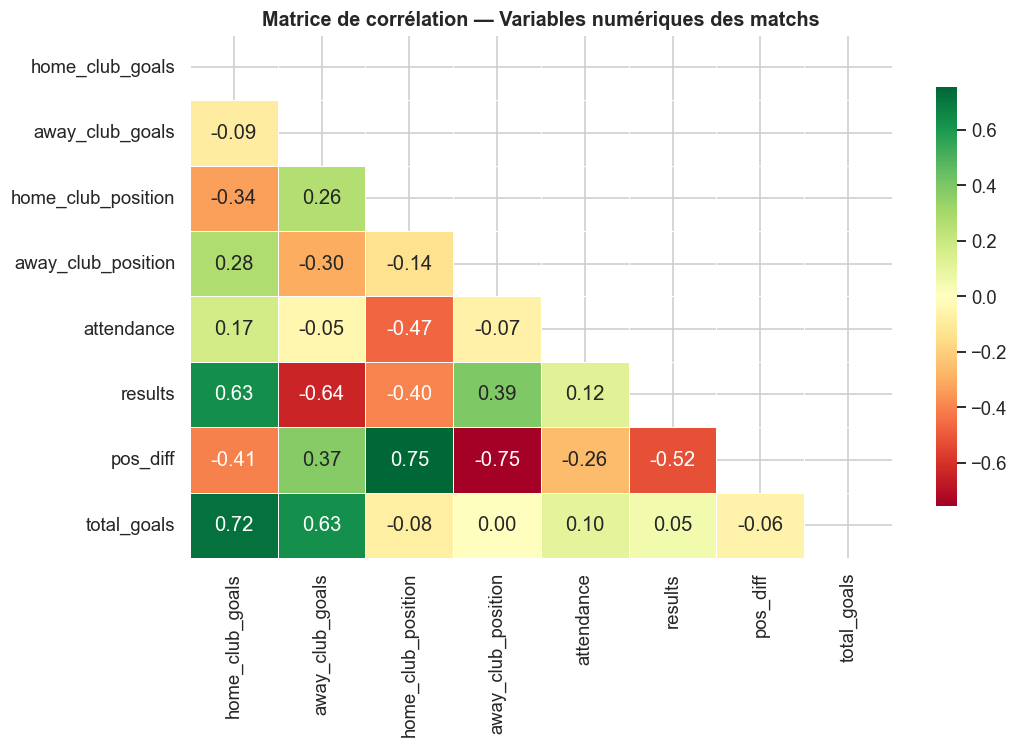

In [11]:
num_cols = ['home_club_goals','away_club_goals','home_club_position',
            'away_club_position','attendance','results','pos_diff','total_goals']
corr = matches[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Matrice de corrélation — Variables numériques des matchs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight :** `home_club_goals` et `away_club_goals` sont fortement corrélés au résultat mais constituent une **fuite de données** — ils ne seront pas utilisés comme features. `home_club_position` et `pos_diff` ont un pouvoir prédictif intéressant et seront conservés.

---
## 4. Prétraitement des Données

In [12]:
# ── 4.1 Valeur marchande — agrégation par club/saison ────────────────────
valuation['season'] = valuation['date'].dt.year - 1
club_val_season = valuation.groupby(['current_club_id','season'])['market_value_in_eur'].agg(
    squad_total_value='sum', squad_avg_value='mean'
).reset_index().rename(columns={'current_club_id':'club_id'})

def parse_transfer(val):
    if pd.isna(val): return 0.0
    v = str(val).replace('€','').replace('+','').strip()
    if v.endswith('m'): return float(v[:-1])*1e6
    if v.endswith('k'): return float(v[:-1])*1e3
    try: return float(v)
    except: return 0.0

clubs['net_transfer_eur'] = clubs['net_transfer_record'].apply(parse_transfer)

# Variable globale utilisée en 5.6 ET en section 11
CLUB_FEAT_COLS = ['club_id','squad_size','average_age','foreigners_percentage',
                  'national_team_players','stadium_seats','net_transfer_eur']
club_feats = clubs[CLUB_FEAT_COLS].copy()

# ── 4.2 Fonction add_valuation — protégée contre le double appel ─────────
def add_valuation_features(df, val_df):
    """Ajoute les features de valeur marchande. Sécurisée contre les doublons."""
    # Supprimer les colonnes si déjà présentes (évite les suffixes _x/_y)
    cols_to_drop = ['home_squad_value','away_squad_value','home_avg_player_value',
                    'away_avg_player_value','squad_value_ratio','squad_value_diff']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
    df = df.merge(
        val_df.rename(columns={'club_id':'home_club_id',
            'squad_total_value':'home_squad_value',
            'squad_avg_value':'home_avg_player_value'}),
        on=['home_club_id','season'], how='left')
    df = df.merge(
        val_df.rename(columns={'club_id':'away_club_id',
            'squad_total_value':'away_squad_value',
            'squad_avg_value':'away_avg_player_value'}),
        on=['away_club_id','season'], how='left')
    df['squad_value_ratio'] = df['home_squad_value']/(df['away_squad_value']+1)
    df['squad_value_diff']  = df['home_squad_value']-df['away_squad_value']
    return df

# ── 4.3 Agrégation appearances par match ─────────────────────────────────
app_per_match = appearances.groupby(['game_id','player_club_id']).agg(
    team_goals_app=('goals','sum'), team_assists=('assists','sum'),
    team_yellow=('yellow_cards','sum'), team_red=('red_cards','sum'),
    team_mins=('minutes_played','mean')
).reset_index()

print('✅ Prétraitement terminé')
print(f'   club_val_season : {club_val_season.shape}')
print(f'   club_feats      : {club_feats.shape}')
print(f'   app_per_match   : {app_per_match.shape}')

✅ Prétraitement terminé
   club_val_season : (747, 4)
   club_feats      : (36, 7)
   app_per_match   : (9351, 7)


---
## 5. Feature Engineering

C'est la **partie la plus critique** du projet. Nous construisons 8 groupes de features :

| # | Feature | Justification |
|---|---|---|
| 1 | **Proxies xG** (type tir, pénalty, timing) | Approche Opta/Statsbomb depuis `game_events` |
| 2 | **Forme récente** (5 derniers matchs) | Momentum, confiance, dynamique récente |
| 3 | **H2H pondéré** (décroissance exponentielle λ=0.85) | Matchs récents plus informatifs |
| 4 | **Absence joueurs clés** | Impact des indisponibilités sur le potentiel offensif |
| 5 | **Performance dom/ext** sur la saison | Asymétrie domicile-extérieur propre à chaque club |
| 6 | **Stats cumulées saison** (buts, series) | Niveau moyen sur la saison |
| 7 | **Valeur marchande** des effectifs | Proxy du niveau long terme |
| 8 | **Features clubs** (effectif, âge, transferts) | Contexte structurel du club |

### 5.1 Proxies xG depuis `game_events`

Faute d'accès aux données Opta/Statsbomb, on extrait les métriques équivalentes depuis les descriptions de buts : type de tir, pénaltys, têtes, buts tardifs, et on associe un **xG approximatif** issu de la littérature.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PROXIES xG — Extraction depuis game_events
# ─────────────────────────────────────────────────────────────────────────────
goals_ev = events[events['type']=='Goals'].copy()
cards_ev  = events[events['type']=='Cards'].copy()

# Parsing des types de buts
goals_ev['shot_type']   = goals_ev['description'].str.extract(r',\s*([^,]+),')[0].str.strip()
goals_ev['is_penalty']  = goals_ev['description'].str.contains('Penalty', case=False, na=False).astype(int)
goals_ev['is_header']   = goals_ev['description'].str.contains('Header', case=False, na=False).astype(int)
goals_ev['is_freekick'] = goals_ev['description'].str.contains('Direct free kick', case=False, na=False).astype(int)
goals_ev['is_counter']  = goals_ev['description'].str.contains('Counter attack', case=False, na=False).astype(int)
goals_ev['is_longdist'] = goals_ev['description'].str.contains('Long distance', case=False, na=False).astype(int)
goals_ev['is_early']    = (goals_ev['minute'] <= 15).astype(int)
goals_ev['is_late']     = (goals_ev['minute'] >= 75).astype(int)

# xG approximatif par type (valeurs issues de la littérature académique)
XG_MAP = {
    'Penalty': 0.79, 'Tap-in': 0.60, 'Right-footed shot': 0.10,
    'Left-footed shot': 0.09, 'Header': 0.08, 'Direct free kick': 0.06,
    'Deflected shot on goal': 0.08, 'Counter attack goal': 0.12,
    'Long distance kick': 0.04, 'Solo run': 0.15,
}
goals_ev['approx_xg'] = goals_ev['shot_type'].map(XG_MAP).fillna(0.09)

# Agrégation par (game_id, club_id)
xg_agg = goals_ev.groupby(['game_id','club_id']).agg(
    nb_goals=('is_penalty','count'), nb_penalties=('is_penalty','sum'),
    nb_headers=('is_header','sum'), nb_late_goals=('is_late','sum'),
    nb_early_goals=('is_early','sum'), total_approx_xg=('approx_xg','sum'),
).reset_index()

xg_home = xg_agg.rename(columns={'club_id':'home_club_id',
    **{c:f'home_{c}' for c in xg_agg.columns if c not in ['game_id','club_id']}})
xg_away = xg_agg.rename(columns={'club_id':'away_club_id',
    **{c:f'away_{c}' for c in xg_agg.columns if c not in ['game_id','club_id']}})
matches = matches.merge(xg_home, on=['game_id','home_club_id'], how='left')
matches = matches.merge(xg_away, on=['game_id','away_club_id'], how='left')

# Cartons
cards_ev['is_red']    = cards_ev['description'].str.contains('Red|red', na=False).astype(int)
cards_ev['is_yellow'] = (cards_ev['is_red']==0).astype(int)
cards_agg = cards_ev.groupby(['game_id','club_id']).agg(
    nb_cards_total=('game_event_id','count'),
    nb_red=('is_red','sum'), nb_yellow=('is_yellow','sum')
).reset_index()
cards_home = cards_agg.rename(columns={'club_id':'home_club_id',
    **{c:f'home_{c}' for c in cards_agg.columns if c not in ['game_id','club_id']}})
cards_away = cards_agg.rename(columns={'club_id':'away_club_id',
    **{c:f'away_{c}' for c in cards_agg.columns if c not in ['game_id','club_id']}})
matches = matches.merge(cards_home, on=['game_id','home_club_id'], how='left')
matches = matches.merge(cards_away, on=['game_id','away_club_id'], how='left')

print(f'✅ Proxies xG et cartons ajoutés | Shape : {matches.shape}')

✅ Proxies xG et cartons ajoutés | Shape : (4691, 44)


In [14]:
# Features glissantes xG (5 derniers matchs) — évite la fuite de données
def compute_rolling_xg(matches_df, n=5):
    df = matches_df.sort_values('date').copy()
    rows = []
    xg_cols_h = ['home_total_approx_xg','home_nb_penalties','home_nb_headers',
                 'home_nb_late_goals','home_nb_cards_total']
    xg_cols_a = ['away_total_approx_xg','away_nb_penalties','away_nb_headers',
                 'away_nb_late_goals','away_nb_cards_total']
    for _, row in df.iterrows():
        hid=row['home_club_id']; aid=row['away_club_id']; date=row['date']
        def get_prev(cid):
            mask=((df['home_club_id']==cid)|(df['away_club_id']==cid))&(df['date']<date)
            return df[mask].tail(n)
        def rolling_stats(prev, cid, cols_h, cols_a):
            res={}
            for ch, ca in zip(cols_h, cols_a):
                vals=[]
                for _,m in prev.iterrows():
                    vals.append((m.get(ch,0) or 0) if m['home_club_id']==cid else (m.get(ca,0) or 0))
                res[ch.replace('home_','rolling_')]= np.mean(vals) if vals else 0
            return res
        rh=rolling_stats(get_prev(hid),hid,xg_cols_h,xg_cols_a)
        ra=rolling_stats(get_prev(aid),aid,xg_cols_h,xg_cols_a)
        entry={'game_id':row['game_id']}
        for k,v in rh.items(): entry[f'home_{k}']=v
        for k,v in ra.items(): entry[f'away_{k}']=v
        rows.append(entry)
    return pd.DataFrame(rows)

print('⏳ Calcul rolling xG features...')
rolling_xg_df = compute_rolling_xg(matches)
print(f'✅ Rolling xG : {rolling_xg_df.shape}')

⏳ Calcul rolling xG features...
✅ Rolling xG : (4691, 11)


**💡 Insight xG :** Les types de tirs différencient la qualité offensive : un pénalty (xG≈0.79) vaut 10× un tir de loin (xG≈0.04). Utiliser les moyennes glissantes de ces métriques permet de capturer le niveau offensif qualitatif de chaque équipe au-delà du simple comptage de buts.

### 5.2 Forme récente (5 derniers matchs)

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FORME RÉCENTE — Pts, buts, wins sur les 5 derniers matchs
# Justification : La dynamique récente capture le momentum et la confiance
# ─────────────────────────────────────────────────────────────────────────────
def compute_recent_form(matches_df, n_games=5):
    df = matches_df.sort_values('date').copy().reset_index(drop=True)
    rows = []
    for idx, row in df.iterrows():
        gid=row['game_id']; hid=row['home_club_id']; aid=row['away_club_id']; date=row['date']
        def get_last_n(cid):
            mask=(df['date']<date)&((df['home_club_id']==cid)|(df['away_club_id']==cid))
            return df[mask].tail(n_games)
        def stats(prev, cid):
            if len(prev)==0: return dict(pts=0,gf=0,ga=0,wins=0,draws=0)
            pts=wins=draws=gf=ga=0
            for _,m in prev.iterrows():
                ih=(m['home_club_id']==cid)
                gf+=m['home_club_goals'] if ih else m['away_club_goals']
                ga+=m['away_club_goals'] if ih else m['home_club_goals']
                res=m['results']
                if (ih and res==1) or (not ih and res==-1): pts+=3;wins+=1
                elif res==0: pts+=1;draws+=1
            n=len(prev)
            return dict(pts=pts/n,gf=gf/n,ga=ga/n,wins=wins/n,draws=draws/n)
        sh=stats(get_last_n(hid),hid); sa=stats(get_last_n(aid),aid)
        pnh=get_last_n(hid); pna=get_last_n(aid)
        rows.append({'game_id':gid,
            'home_form_pts':sh['pts'],'home_form_gf':sh['gf'],'home_form_ga':sh['ga'],
            'home_form_wins':sh['wins'],'home_form_draws':sh['draws'],'home_form_n':len(pnh),
            'away_form_pts':sa['pts'],'away_form_gf':sa['gf'],'away_form_ga':sa['ga'],
            'away_form_wins':sa['wins'],'away_form_draws':sa['draws'],'away_form_n':len(pna),
            'form_pts_diff':sh['pts']-sa['pts'],
            'form_gf_diff':sh['gf']-sa['gf'],
            'form_ga_diff':sh['ga']-sa['ga']})
    return pd.DataFrame(rows)

print('⏳ Calcul forme récente (peut prendre ~2 min)...')
form_df = compute_recent_form(matches)
print(f'✅ Forme calculée : {form_df.shape}')

⏳ Calcul forme récente (peut prendre ~2 min)...
✅ Forme calculée : (4691, 16)


### 5.3 H2H Pondéré (Décroissance exponentielle λ=0.85)

Les matchs anciens sont moins informatifs : les effectifs, entraîneurs et styles de jeu évoluent. On applique `w = 0.85^(jours/365)` — un match d'il y a 18 mois ne pèse plus que 0.5× un match récent.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# H2H PONDÉRÉ — Décroissance exponentielle
# Justification : matchs récents > matchs anciens (effectifs, tactiques changent)
# ─────────────────────────────────────────────────────────────────────────────
DECAY = 0.85

def compute_h2h_weighted(matches_df, n=10, decay=DECAY):
    df = matches_df.sort_values('date').copy()
    rows = []
    for _, row in df.iterrows():
        hid=row['home_club_id']; aid=row['away_club_id']; date=row['date']
        prev = df[(df['date']<date)&(
            ((df['home_club_id']==hid)&(df['away_club_id']==aid))|
            ((df['home_club_id']==aid)&(df['away_club_id']==hid))
        )].tail(n)
        if len(prev)==0:
            rows.append({'game_id':row['game_id'],
                'h2h_w_home_wins':0.33,'h2h_w_away_wins':0.30,'h2h_w_draws':0.26,
                'h2h_w_home_gf':1.4,'h2h_w_away_gf':1.1,'h2h_n':0,'h2h_recency':0.0,
                'h2h_home_wins':0.33,'h2h_away_wins':0.30,'h2h_draws':0.26})
            continue
        days_ago=[(date-m_date).days for m_date in prev['date']]
        weights=np.array([decay**(d/365.) for d in days_ago])
        weights/=weights.sum()
        hw_w=aw_w=d_w=hgf_w=agf_w=hw_u=aw_u=d_u=0.0
        for (_,m),w in zip(prev.iterrows(),weights):
            ih=(m['home_club_id']==hid)
            gf=m['home_club_goals'] if ih else m['away_club_goals']
            ga=m['away_club_goals'] if ih else m['home_club_goals']
            res=m['results']
            hw=(ih and res==1) or (not ih and res==-1)
            aw=(ih and res==-1) or (not ih and res==1)
            hgf_w+=gf*w; agf_w+=ga*w
            if hw: hw_w+=w;hw_u+=1
            elif aw: aw_w+=w;aw_u+=1
            else: d_w+=w;d_u+=1
        np_=len(prev)
        rows.append({'game_id':row['game_id'],
            'h2h_w_home_wins':hw_w,'h2h_w_away_wins':aw_w,'h2h_w_draws':d_w,
            'h2h_w_home_gf':hgf_w,'h2h_w_away_gf':agf_w,'h2h_n':np_,
            'h2h_recency':weights[-1] if len(weights)>0 else 0,
            'h2h_home_wins':hw_u/np_,'h2h_away_wins':aw_u/np_,'h2h_draws':d_u/np_})
    return pd.DataFrame(rows)

print(f'⏳ Calcul H2H pondéré (λ={DECAY})...')
h2h_df = compute_h2h_weighted(matches)
print(f'✅ H2H pondéré : {h2h_df.shape}')

⏳ Calcul H2H pondéré (λ=0.85)...
✅ H2H pondéré : (4691, 11)


### 5.4 Absence des joueurs clés

On identifie les top 5 joueurs par club (impact = buts + 0.7×passes), puis on vérifie leur présence dans le 11 de départ. Le score d'absence = somme des impacts des absents.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# ABSENCE JOUEURS CLÉS — Impact score × présence dans le lineup
# Justification : l'absence d'un joueur clé réduit le potentiel offensif
# ─────────────────────────────────────────────────────────────────────────────
player_impact = appearances.groupby(['player_id','player_club_id']).agg(
    total_goals=('goals','sum'), total_assists=('assists','sum'),
    total_apps=('game_id','count')
).reset_index()
player_impact['impact_score'] = player_impact['total_goals'] + 0.7*player_impact['total_assists']

# Top 5 joueurs clés par club (min 5 matchs)
key_players = (
    player_impact[player_impact['total_apps']>=5]
    .sort_values(['player_club_id','impact_score'],ascending=[True,False])
    .groupby('player_club_id').head(5)
)
key_by_club = key_players.groupby('player_club_id').apply(
    lambda g: list(zip(g['player_id'],g['impact_score']))
).to_dict()

# Titulaires par match
starters = lineups[lineups['type']=='starting_lineup'][['game_id','player_id','club_id']]
starters_dict = starters.groupby(['game_id','club_id'])['player_id'].apply(set).to_dict()

def absence_score(gid, cid):
    key = key_by_club.get(cid,[])
    if not key: return 0.0, 0
    lineup = starters_dict.get((gid,cid), set())
    if not lineup: return 0.0, 0
    s=0.0; n=0
    for pid,imp in key:
        if pid not in lineup: s+=imp; n+=1
    return s, n

print('⏳ Calcul scores d\'absence...')
abs_rows=[]
for _,row in matches.iterrows():
    gid=row['game_id']; hid=row['home_club_id']; aid=row['away_club_id']
    hs,hn=absence_score(gid,hid); as_,an=absence_score(gid,aid)
    abs_rows.append({'game_id':gid,'home_absence_score':hs,'away_absence_score':as_,
        'home_nb_absent_key':hn,'away_nb_absent_key':an,'absence_score_diff':hs-as_})
absence_df = pd.DataFrame(abs_rows)
print(f'✅ Scores d\'absence : {absence_df.shape}')

⏳ Calcul scores d'absence...
✅ Scores d'absence : (4691, 6)


### 5.5 Performance domicile/extérieur et statistiques de saison

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# STATS DOM/EXT ET CUMULÉES DE SAISON
# Justification : certaines équipes très fortes à dom. mais fragiles à l'ext.
# ─────────────────────────────────────────────────────────────────────────────
def compute_season_and_home_away(df):
    df = df.sort_values(['season','date']).copy()
    rows=[]
    for _,row in df.iterrows():
        s=row['season']; d=row['date']; hid=row['home_club_id']; aid=row['away_club_id']
        # Dom/ext
        ph=df[(df['season']==s)&(df['date']<d)&(df['home_club_id']==hid)]
        pa=df[(df['season']==s)&(df['date']<d)&(df['away_club_id']==aid)]
        # Saison cumulée
        def cum(cid):
            ch=df[(df['season']==s)&(df['date']<d)&(df['home_club_id']==cid)]
            ca=df[(df['season']==s)&(df['date']<d)&(df['away_club_id']==cid)]
            gf=ch['home_club_goals'].sum()+ca['away_club_goals'].sum()
            ga=ch['away_club_goals'].sum()+ca['home_club_goals'].sum()
            n=len(ch)+len(ca)
            return gf/n if n else 0, ga/n if n else 0, n
        hgf,hga,hn=cum(hid); agf,aga,an=cum(aid)
        rows.append({'game_id':row['game_id'],
            'home_home_winrate':(ph['results']==1).mean() if len(ph) else 0,
            'home_home_n':len(ph),
            'home_home_gf_avg':ph['home_club_goals'].mean() if len(ph) else 0,
            'home_home_ga_avg':ph['away_club_goals'].mean() if len(ph) else 0,
            'away_away_winrate':(pa['results']==-1).mean() if len(pa) else 0,
            'away_away_n':len(pa),
            'away_away_gf_avg':pa['away_club_goals'].mean() if len(pa) else 0,
            'away_away_ga_avg':pa['home_club_goals'].mean() if len(pa) else 0,
            'home_season_gf':hgf,'home_season_ga':hga,'home_season_n':hn,
            'away_season_gf':agf,'away_season_ga':aga,'away_season_n':an,
            'season_gf_diff':hgf-agf,'season_ga_diff':hga-aga})
    return pd.DataFrame(rows)

print('⏳ Calcul stats saison + dom/ext...')
season_stats_df = compute_season_and_home_away(matches)
print(f'✅ Stats saison : {season_stats_df.shape}')

⏳ Calcul stats saison + dom/ext...
✅ Stats saison : (4691, 17)


### 5.6 Valeur marchande et features clubs

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# VALEUR MARCHANDE + FEATURES CLUBS
# Justification : effectif plus cher = niveau long terme supérieur
# ─────────────────────────────────────────────────────────────────────────────
matches = add_valuation_features(matches, club_val_season)

club_feats = clubs[['club_id','squad_size','average_age','foreigners_percentage',
                    'national_team_players','stadium_seats','net_transfer_eur']]
matches = matches.merge(
    club_feats.rename(columns={c:f'home_{c}' for c in club_feats.columns if c!='club_id'
                               }).rename(columns={'club_id':'home_club_id'}),
    on='home_club_id', how='left')
matches = matches.merge(
    club_feats.rename(columns={c:f'away_{c}' for c in club_feats.columns if c!='club_id'
                               }).rename(columns={'club_id':'away_club_id'}),
    on='away_club_id', how='left')

# Features de classement
matches['pos_diff']          = matches['home_club_position'] - matches['away_club_position']
matches['pos_ratio']         = matches['home_club_position'] / (matches['away_club_position']+1)
matches['home_is_top_half']  = (matches['home_club_position']<=10).astype(int)
matches['away_is_top_half']  = (matches['away_club_position']<=10).astype(int)

print(f'✅ Valuation + clubs ajoutés | Shape : {matches.shape}')

✅ Valuation + clubs ajoutés | Shape : (4691, 65)


### 5.7 Assemblage du dataset final et visualisation des features

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# ASSEMBLAGE FINAL
# ─────────────────────────────────────────────────────────────────────────────
dataset = matches.copy()
dataset = dataset.merge(form_df,         on='game_id', how='left')
dataset = dataset.merge(h2h_df,          on='game_id', how='left')
dataset = dataset.merge(absence_df,      on='game_id', how='left')
dataset = dataset.merge(season_stats_df, on='game_id', how='left')
dataset = dataset.merge(rolling_xg_df,   on='game_id', how='left')

print(f'✅ Dataset final : {dataset.shape}')

✅ Dataset final : (4691, 121)


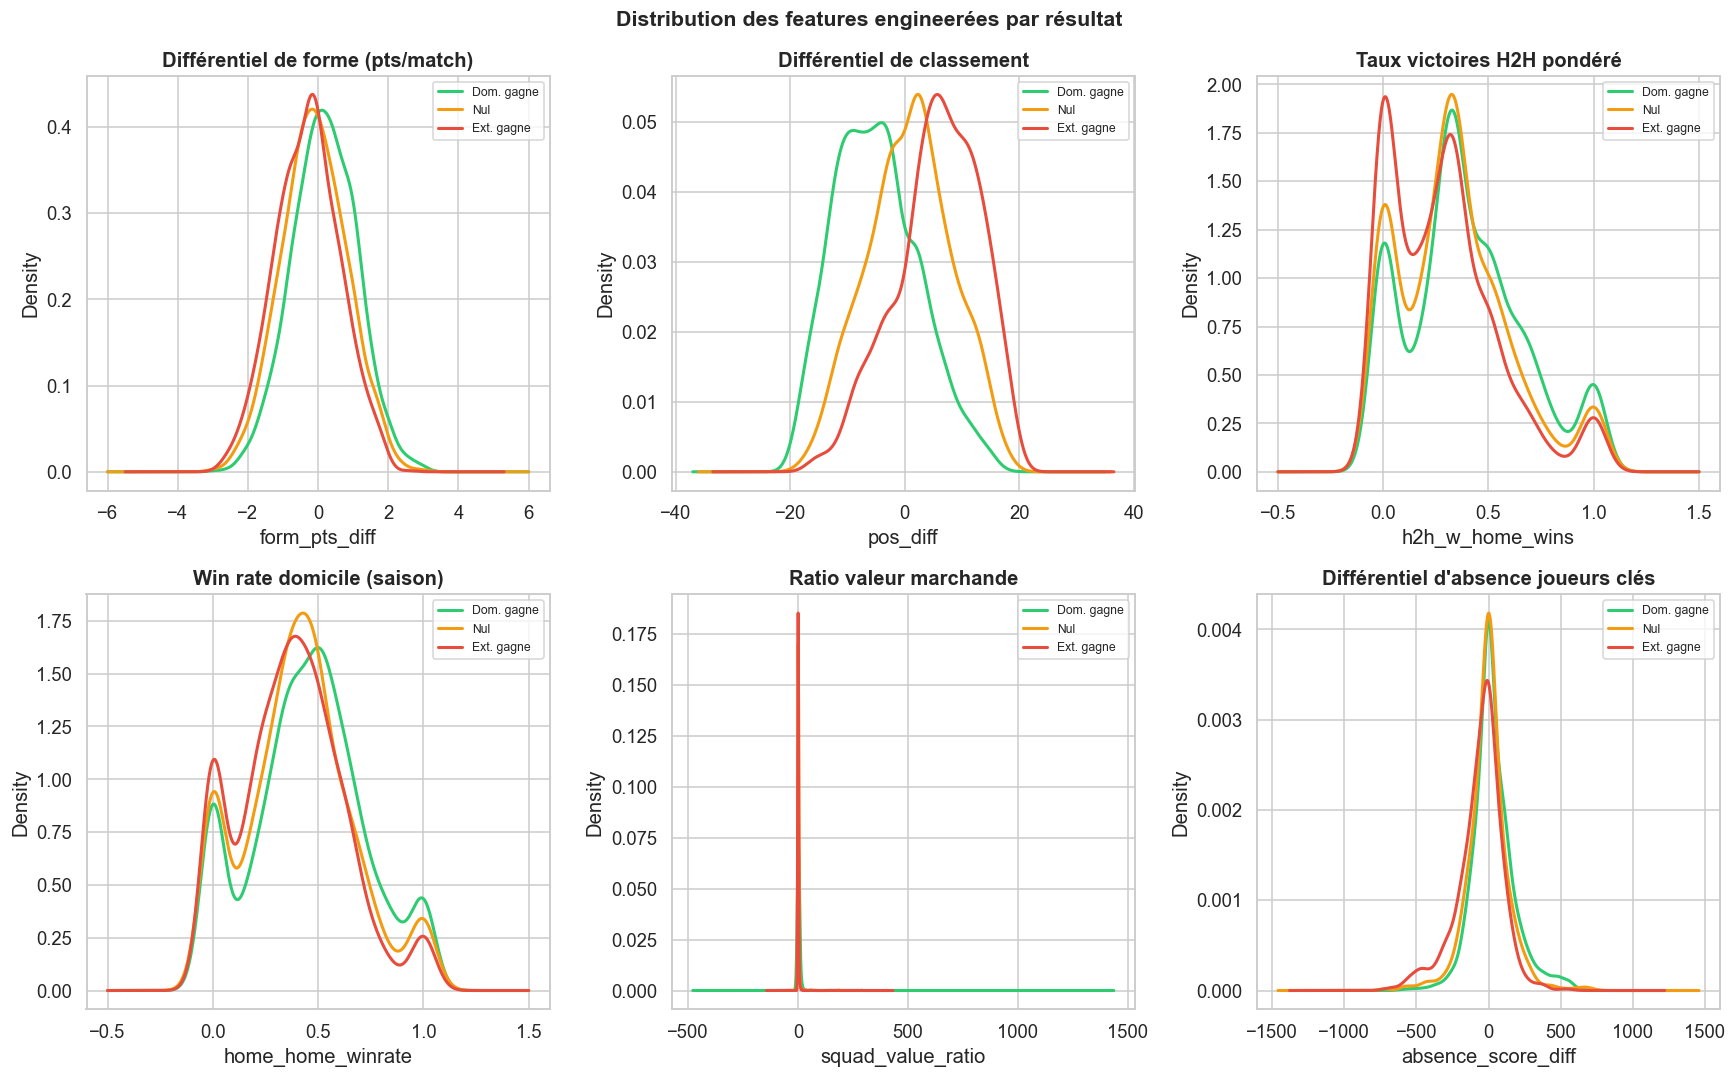

In [21]:
# Visualisation de l'impact des features engineerées
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
features_to_plot = [
    ('form_pts_diff',       'Différentiel de forme (pts/match)'),
    ('pos_diff',            'Différentiel de classement'),
    ('h2h_w_home_wins',     'Taux victoires H2H pondéré'),
    ('home_home_winrate',   'Win rate domicile (saison)'),
    ('squad_value_ratio',   'Ratio valeur marchande'),
    ('absence_score_diff',  'Différentiel d\'absence joueurs clés'),
]
colors_res={1:'#2ecc71',0:'#f39c12',-1:'#e74c3c'}
labels_res={1:'Dom. gagne',0:'Nul',-1:'Ext. gagne'}

for ax,(feat,title) in zip(axes,features_to_plot):
    if feat not in dataset.columns: ax.set_visible(False); continue
    for res in [1,0,-1]:
        sub=dataset[dataset['results']==res][feat].dropna()
        if len(sub)>1:
            sub.plot(kind='kde',ax=ax,label=labels_res[res],color=colors_res[res],linewidth=2)
    ax.set_title(title,fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.suptitle('Distribution des features engineerées par résultat',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight :** Les distributions sont bien séparées selon le résultat pour `form_pts_diff`, `pos_diff`, `h2h_w_home_wins` et `squad_value_ratio`. Le H2H pondéré est plus discriminant que le H2H brut car il reflète mieux la dynamique actuelle entre les deux équipes.

---
## 6. Préparation des Données pour le ML

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SÉLECTION DES FEATURES — Sans data leakage
# ─────────────────────────────────────────────────────────────────────────────
EXCLUDE = [
    'game_id','season','round','date','results',
    'home_club_goals','away_club_goals',      # ← data leakage !
    'home_club_name','away_club_name',
    'home_club_manager_name','away_club_manager_name',
    'stadium','referee','aggregate','competition_type',
    'home_club_formation','away_club_formation',
    'result_label','total_goals','Unnamed: 0',
    # Métriques du match en cours (leakage)
    'home_total_approx_xg','away_total_approx_xg',
    'home_nb_goals','away_nb_goals',
    'home_nb_penalties','away_nb_penalties',
    'home_nb_headers','away_nb_headers',
    'home_nb_late_goals','away_nb_late_goals',
    'home_nb_early_goals','away_nb_early_goals',
    'home_nb_cards_total','away_nb_cards_total',
    'home_nb_red','away_nb_red',
    'home_nb_yellow','away_nb_yellow',
]

FEATURE_COLS = [c for c in dataset.columns if c not in EXCLUDE]
print(f'Nombre de features : {len(FEATURE_COLS)}')
print('Features sélectionnées :')
for c in FEATURE_COLS:
    print(f'  - {c}')

Nombre de features : 83
Features sélectionnées :
  - home_club_id
  - away_club_id
  - home_club_position
  - away_club_position
  - attendance
  - pos_diff
  - home_squad_value
  - home_avg_player_value
  - away_squad_value
  - away_avg_player_value
  - squad_value_ratio
  - squad_value_diff
  - home_squad_size
  - home_average_age
  - home_foreigners_percentage
  - home_national_team_players
  - home_stadium_seats
  - home_net_transfer_eur
  - away_squad_size
  - away_average_age
  - away_foreigners_percentage
  - away_national_team_players
  - away_stadium_seats
  - away_net_transfer_eur
  - pos_ratio
  - home_is_top_half
  - away_is_top_half
  - home_form_pts
  - home_form_gf
  - home_form_ga
  - home_form_wins
  - home_form_draws
  - home_form_n
  - away_form_pts
  - away_form_gf
  - away_form_ga
  - away_form_wins
  - away_form_draws
  - away_form_n
  - form_pts_diff
  - form_gf_diff
  - form_ga_diff
  - h2h_w_home_wins
  - h2h_w_away_wins
  - h2h_w_draws
  - h2h_w_home_gf
  - h2

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# ENCODAGE, IMPUTATION, SPLIT
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
all_clubs = pd.concat([dataset['home_club_id'],dataset['away_club_id'],
                       m2025['home_club_id'],m2025['away_club_id']]).unique()
le.fit(all_clubs)
dataset['home_club_id'] = le.transform(dataset['home_club_id'])
dataset['away_club_id'] = le.transform(dataset['away_club_id'])

X = dataset[FEATURE_COLS].copy()
y = dataset['results'].copy()

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split temporel : 2012-2023 → train | 2024 → test
train_mask = dataset['season'].values < 2024
test_mask  = dataset['season'].values >= 2024
X_train, X_test = X_imp[train_mask], X_imp[test_mask]
y_train, y_test = y.values[train_mask], y.values[test_mask]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} matchs (2012–2023)')
print(f'Test  : {X_test.shape[0]} matchs (2024)')
print(f'y_train : {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'y_test  : {dict(zip(*np.unique(y_test,  return_counts=True)))}')

Train : 4385 matchs (2012–2023)
Test  : 306 matchs (2024)
y_train : {np.int64(-1): np.int64(1309), np.int64(0): np.int64(1154), np.int64(1): np.int64(1922)}
y_test  : {np.int64(-1): np.int64(101), np.int64(0): np.int64(62), np.int64(1): np.int64(143)}


**Note méthodologique :** On utilise un **split temporel** (et non aléatoire) : on entraîne sur 2012–2023 et on teste sur 2024. C'est crucial pour éviter la fuite d'information future dans le modèle.

---
## 7. Modélisation

Nous testons 7 modèles couvrant différentes familles algorithmiques, plus un LSTM pour les séries temporelles.

In [24]:
# Setup commun
baseline_acc = (y_test == 1).mean()
results_models = {}
label_map_xgb = {-1:0, 0:1, 1:2}
label_unmap   = {0:-1, 1:0, 2:1}
y_train_xgb = np.array([label_map_xgb[v] for v in y_train])
y_test_xgb  = np.array([label_map_xgb[v] for v in y_test])

def evaluate(name, model, Xtr, ytr, Xte, yte, xgb_labels=False):
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    if xgb_labels:
        preds = np.array([label_unmap[p] for p in preds])
        yte = np.array([label_unmap[p] for p in yte])
    acc = accuracy_score(yte, preds)
    results_models[name] = {'accuracy':acc,'preds':preds,'model':model}
    print(f'{name:35s} → Accuracy = {acc:.4f}')
    return acc

print(f'Baseline (toujours victoire dom.) : {baseline_acc:.4f}\n')
print('⏳ Entraînement des modèles...\n')

Baseline (toujours victoire dom.) : 0.4673

⏳ Entraînement des modèles...



In [25]:
# ── 7.1 Régression Logistique ────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=0.5, random_state=SEED, multi_class='multinomial')
evaluate('Logistic Regression', lr, X_train_sc, y_train, X_test_sc, y_test)
print(classification_report(y_test, results_models['Logistic Regression']['preds'],
                             target_names=['Ext. gagne','Nul','Dom. gagne']))

Logistic Regression                 → Accuracy = 0.6078
              precision    recall  f1-score   support

  Ext. gagne       0.59      0.53      0.56       101
         Nul       0.31      0.21      0.25        62
  Dom. gagne       0.69      0.83      0.76       143

    accuracy                           0.61       306
   macro avg       0.53      0.53      0.52       306
weighted avg       0.58      0.61      0.59       306



In [26]:
# ── 7.2 Decision Tree ────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=SEED)
evaluate('Decision Tree', dt, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['Decision Tree']['preds'],
                             target_names=['Ext. gagne','Nul','Dom. gagne']))

Decision Tree                       → Accuracy = 0.6111
              precision    recall  f1-score   support

  Ext. gagne       0.71      0.62      0.66       101
         Nul       0.29      0.39      0.33        62
  Dom. gagne       0.75      0.70      0.72       143

    accuracy                           0.61       306
   macro avg       0.58      0.57      0.57       306
weighted avg       0.64      0.61      0.62       306



In [27]:
# ── 7.3 Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                             random_state=SEED, n_jobs=-1)
evaluate('Random Forest', rf, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['Random Forest']['preds'],
                             target_names=['Ext. gagne','Nul','Dom. gagne']))

Random Forest                       → Accuracy = 0.6275
              precision    recall  f1-score   support

  Ext. gagne       0.62      0.67      0.65       101
         Nul       0.56      0.08      0.14        62
  Dom. gagne       0.63      0.83      0.72       143

    accuracy                           0.63       306
   macro avg       0.60      0.53      0.50       306
weighted avg       0.61      0.63      0.58       306



In [28]:
# ── 7.4 Gradient Boosting ────────────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, random_state=SEED)
evaluate('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['Gradient Boosting']['preds'],
                             target_names=['Ext. gagne','Nul','Dom. gagne']))

Gradient Boosting                   → Accuracy = 0.6699
              precision    recall  f1-score   support

  Ext. gagne       0.70      0.65      0.68       101
         Nul       0.42      0.40      0.41        62
  Dom. gagne       0.75      0.80      0.77       143

    accuracy                           0.67       306
   macro avg       0.62      0.62      0.62       306
weighted avg       0.67      0.67      0.67       306



In [29]:
# ── 7.5 XGBoost ──────────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                     subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss',
                     random_state=SEED, n_jobs=-1, verbosity=0)
evaluate('XGBoost', xgb, X_train, y_train_xgb, X_test, y_test_xgb, xgb_labels=True)
print(classification_report(y_test, results_models['XGBoost']['preds'],
                             target_names=['Ext. gagne','Nul','Dom. gagne']))

XGBoost                             → Accuracy = 0.6634
              precision    recall  f1-score   support

  Ext. gagne       0.71      0.69      0.70       101
         Nul       0.41      0.31      0.35        62
  Dom. gagne       0.70      0.80      0.75       143

    accuracy                           0.66       306
   macro avg       0.61      0.60      0.60       306
weighted avg       0.65      0.66      0.65       306



In [30]:
# ── 7.6 LightGBM ─────────────────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                            num_leaves=31, subsample=0.8, random_state=SEED,
                            n_jobs=-1, verbose=-1)
evaluate('LightGBM', lgbm, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['LightGBM']['preds'],
                             target_names=['Ext. gagne','Nul','Dom. gagne']))

LightGBM                            → Accuracy = 0.6569
              precision    recall  f1-score   support

  Ext. gagne       0.66      0.67      0.67       101
         Nul       0.39      0.35      0.37        62
  Dom. gagne       0.76      0.78      0.77       143

    accuracy                           0.66       306
   macro avg       0.60      0.60      0.60       306
weighted avg       0.65      0.66      0.65       306



In [31]:
# ── 7.7 LSTM Double-Branche (Séries Temporelles) ─────────────────────────
SEQ_LEN = 10
LSTM_FEATURES_NAMES = ['goals_scored','goals_conceded','won','drawn','lost','is_home','opp_pos_norm']
N_FEAT = len(LSTM_FEATURES_NAMES)

def build_lstm_sequences(matches_df, seq_len=SEQ_LEN):
    df = matches_df.sort_values('date').copy().reset_index(drop=True)
    def get_seq(cid, before_idx):
        prev = df[(df.index<before_idx)&
                  ((df['home_club_id']==cid)|(df['away_club_id']==cid))].tail(seq_len)
        seq=[]
        for _,m in prev.iterrows():
            ih=int(m['home_club_id']==cid)
            gf=m['home_club_goals'] if ih else m['away_club_goals']
            ga=m['away_club_goals'] if ih else m['home_club_goals']
            res=m['results']
            won=int((ih and res==1)or(not ih and res==-1))
            drw=int(res==0)
            lst=int((ih and res==-1)or(not ih and res==1))
            opp=m['away_club_position'] if ih else m['home_club_position']
            seq.append([gf,ga,won,drw,lst,ih,opp/20.])
        while len(seq)<seq_len: seq.insert(0,[0.]*N_FEAT)
        return np.array(seq[-seq_len:],dtype=np.float32)
    Xh,Xa,yl,gids=[],[],[],[]
    lmap={-1:0,0:1,1:2}
    for idx,row in df.iterrows():
        if idx<seq_len: continue
        Xh.append(get_seq(row['home_club_id'],idx))
        Xa.append(get_seq(row['away_club_id'],idx))
        yl.append(lmap[row['results']])
        gids.append(row['game_id'])
    return np.array(Xh),np.array(Xa),np.array(yl),np.array(gids)

print('⏳ Construction des séquences LSTM...')
Xh_all,Xa_all,yl_all,gids_all = build_lstm_sequences(matches)
ms_all = matches.sort_values('date').iloc[SEQ_LEN:]['season'].values
tr_l = ms_all<2024; te_l = ms_all>=2024
Xh_tr,Xh_te = Xh_all[tr_l],Xh_all[te_l]
Xa_tr,Xa_te = Xa_all[tr_l],Xa_all[te_l]
yl_tr,yl_te = yl_all[tr_l],yl_all[te_l]

inp_h = Input(shape=(SEQ_LEN,N_FEAT), name='home')
inp_a = Input(shape=(SEQ_LEN,N_FEAT), name='away')
xh = LSTM(64,return_sequences=True)(inp_h); xh=Dropout(0.3)(xh); xh=LSTM(32)(xh); xh=BatchNormalization()(xh)
xa = LSTM(64,return_sequences=True)(inp_a); xa=Dropout(0.3)(xa); xa=LSTM(32)(xa); xa=BatchNormalization()(xa)
merged=Concatenate()([xh,xa])
x=Dense(64,activation='relu')(merged); x=Dropout(0.3)(x); x=Dense(32,activation='relu')(x)
out=Dense(3,activation='softmax')(x)
lstm_model=Model(inputs=[inp_h,inp_a],outputs=out)
lstm_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

print('⏳ Entraînement LSTM...')
history=lstm_model.fit(
    [Xh_tr,Xa_tr], to_categorical(yl_tr,3),
    validation_data=([Xh_te,Xa_te],to_categorical(yl_te,3)),
    epochs=100, batch_size=64, verbose=0,
    callbacks=[EarlyStopping(monitor='val_accuracy',patience=15,restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=7,min_lr=1e-5)]
)
lstm_preds_raw  = lstm_model.predict([Xh_te,Xa_te],verbose=0)
lstm_preds_orig = np.array([label_unmap[p] for p in np.argmax(lstm_preds_raw,axis=1)])
y_te_lstm_orig  = np.array([label_unmap[p] for p in yl_te])
acc_lstm = accuracy_score(y_te_lstm_orig, lstm_preds_orig)
results_models['LSTM Double-Branche'] = {'accuracy':acc_lstm,'preds':lstm_preds_orig,'model':lstm_model}
print(f'LSTM Double-Branche                  → Accuracy = {acc_lstm:.4f}')

⏳ Construction des séquences LSTM...
⏳ Entraînement LSTM...
LSTM Double-Branche                  → Accuracy = 0.5621


---
## 8. Évaluation des Modèles

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.1 Tableau comparatif
# ─────────────────────────────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {'Modèle':name,'Accuracy Test':info['accuracy']}
    for name,info in results_models.items()
]).sort_values('Accuracy Test',ascending=False).reset_index(drop=True)
comparison['vs Baseline (+/-)'] = (comparison['Accuracy Test']-baseline_acc).round(4)

print(f'Baseline (toujours dom.) : {baseline_acc:.4f}\n')
display(comparison.style
    .background_gradient(subset=['Accuracy Test'],cmap='YlGn')
    .format({'Accuracy Test':'{:.4f}','vs Baseline (+/-)':'{:+.4f}'})
)

Baseline (toujours dom.) : 0.4673



,Modèle,Accuracy Test,vs Baseline (+/-)
0,Gradient Boosting,0.6699,+0.2026
1,XGBoost,0.6634,+0.1961
2,LightGBM,0.6569,+0.1895
3,Random Forest,0.6275,+0.1601
4,Decision Tree,0.6111,+0.1438
5,Logistic Regression,0.6078,+0.1405
6,LSTM Double-Branche,0.5621,+0.0948


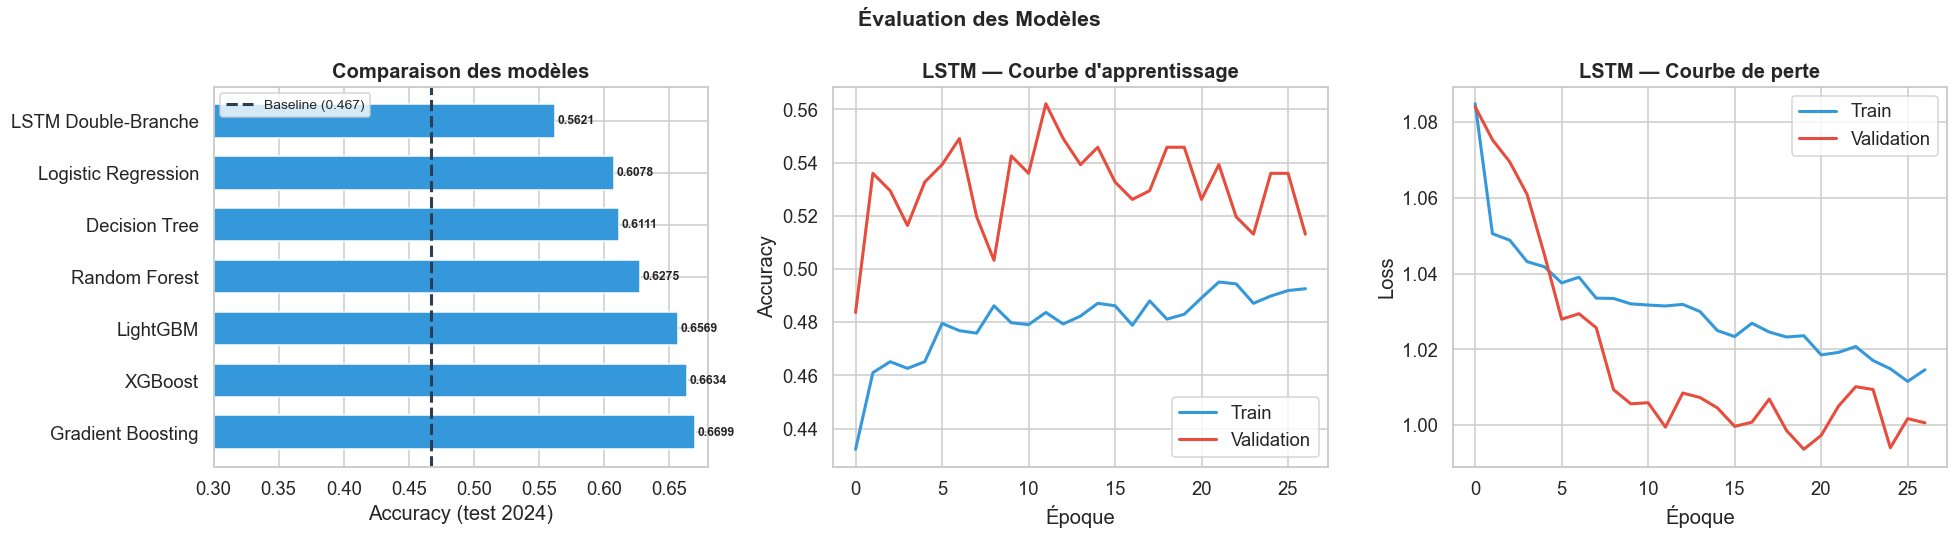

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.2 Visualisation comparative + courbes d'apprentissage LSTM
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barplot comparaison
bar_colors = ['#3498db' if v > baseline_acc else '#e74c3c' for v in comparison['Accuracy Test']]
bars = axes[0].barh(comparison['Modèle'], comparison['Accuracy Test'],
                    color=bar_colors, edgecolor='white', height=0.65)
axes[0].axvline(baseline_acc, color='#2c3e50', linestyle='--', linewidth=2,
                label=f'Baseline ({baseline_acc:.3f})')
for bar, val in zip(bars, comparison['Accuracy Test']):
    axes[0].text(val+0.002, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
axes[0].set_xlim(0.3, 0.68)
axes[0].set_title('Comparaison des modèles', fontweight='bold')
axes[0].set_xlabel('Accuracy (test 2024)')
axes[0].legend(fontsize=9)

# Courbes LSTM
axes[1].plot(history.history['accuracy'],    label='Train',      color='#3498db', linewidth=2)
axes[1].plot(history.history['val_accuracy'],label='Validation', color='#e74c3c', linewidth=2)
axes[1].set_title('LSTM — Courbe d\'apprentissage', fontweight='bold')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(history.history['loss'],    label='Train',      color='#3498db', linewidth=2)
axes[2].plot(history.history['val_loss'],label='Validation', color='#e74c3c', linewidth=2)
axes[2].set_title('LSTM — Courbe de perte', fontweight='bold')
axes[2].set_xlabel('Époque'); axes[2].set_ylabel('Loss'); axes[2].legend()

plt.suptitle('Évaluation des Modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

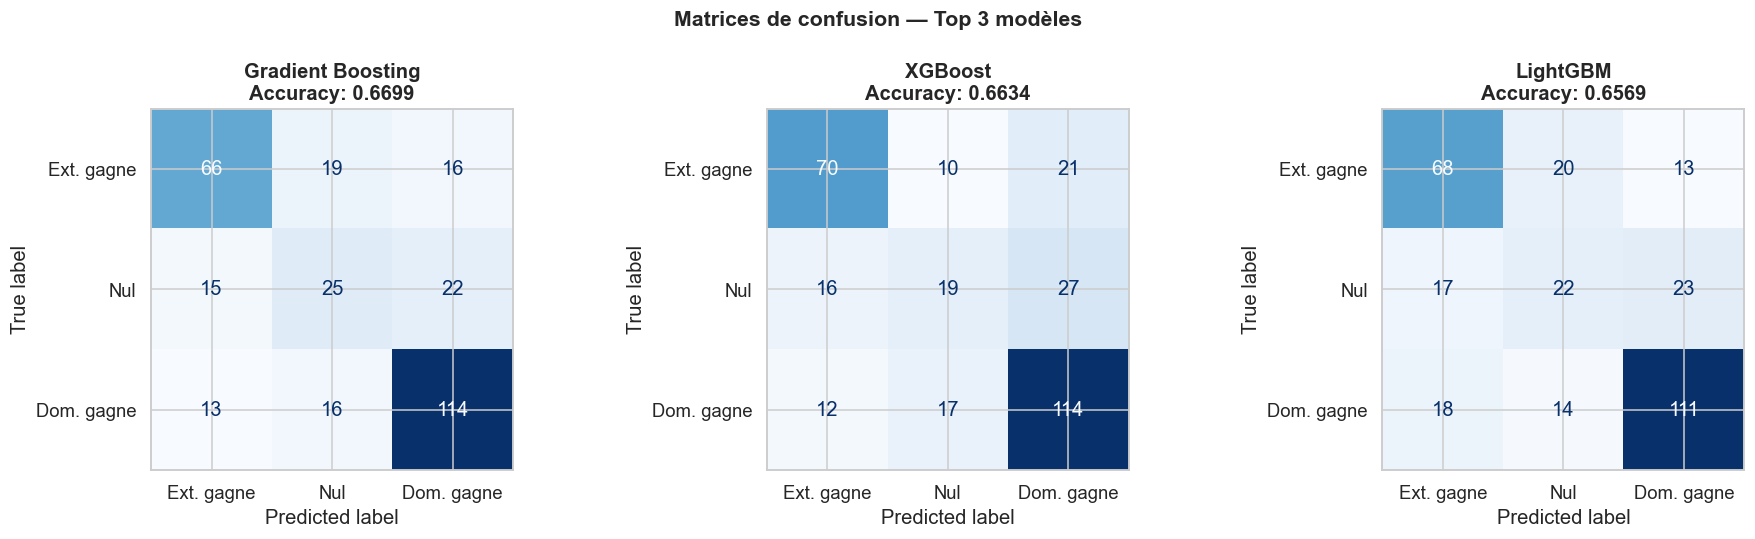

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.3 Matrices de confusion — Top 3 modèles
# ─────────────────────────────────────────────────────────────────────────────
top3 = comparison.head(3)['Modèle'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, name in zip(axes, top3):
    y_true = y_te_lstm_orig if name=='LSTM Double-Branche' else y_test
    cm = confusion_matrix(y_true, results_models[name]['preds'], labels=[-1,0,1])
    ConfusionMatrixDisplay(cm, display_labels=['Ext. gagne','Nul','Dom. gagne']
                          ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {results_models[name]["accuracy"]:.4f}', fontweight='bold')

plt.suptitle('Matrices de confusion — Top 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Analyse :** Tous les modèles peinent sur les **matchs nuls** (classe minoritaire et naturellement imprévisible). Les victoires à domicile sont mieux prédites, car c'est la classe majoritaire avec les signaux les plus clairs (position, forme, H2H).

---
## 9. Amélioration du Modèle

### 9.1 Feature Importance

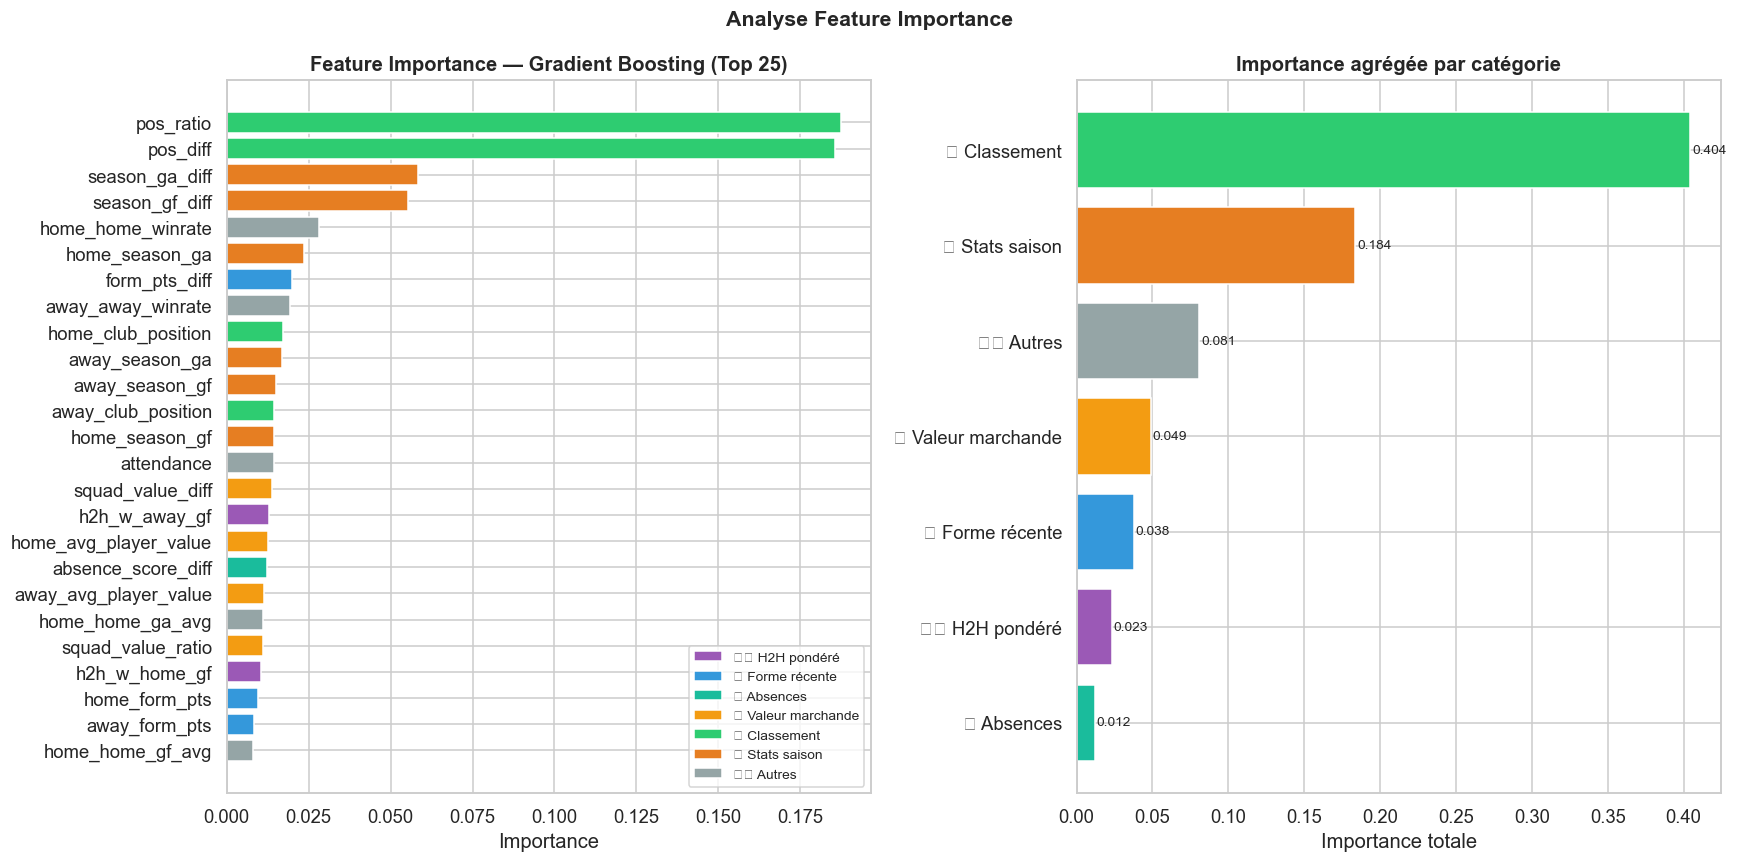

In [35]:
best_tree_name = [n for n in comparison['Modèle'] if n in
    ['LightGBM','Random Forest','XGBoost','Gradient Boosting']][0]
importances = pd.Series(
    results_models[best_tree_name]['model'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(25)

def categorize(feat):
    if any(x in feat for x in ['xg','rolling']): return '🎯 xG proxy'
    if 'h2h' in feat: return '⚔️ H2H pondéré'
    if 'form' in feat: return '📈 Forme récente'
    if 'absence' in feat: return '🚑 Absences'
    if any(x in feat for x in ['squad_value','avg_player']): return '💰 Valeur marchande'
    if 'pos' in feat: return '📊 Classement'
    if 'season' in feat: return '📅 Stats saison'
    return '⚙️ Autres'

feat_df = importances.reset_index()
feat_df.columns = ['feature','importance']
feat_df['category'] = feat_df['feature'].apply(categorize)
cat_colors = {'🎯 xG proxy':'#e74c3c','⚔️ H2H pondéré':'#9b59b6',
    '📈 Forme récente':'#3498db','🚑 Absences':'#1abc9c',
    '💰 Valeur marchande':'#f39c12','📊 Classement':'#2ecc71',
    '📅 Stats saison':'#e67e22','⚙️ Autres':'#95a5a6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
bar_fi = [cat_colors.get(c,'#95a5a6') for c in feat_df['category']]
axes[0].barh(feat_df['feature'],feat_df['importance'],color=bar_fi,edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title(f'Feature Importance — {best_tree_name} (Top 25)',fontweight='bold')
axes[0].set_xlabel('Importance')
legend_el=[Patch(facecolor=c,label=k) for k,c in cat_colors.items() if k in feat_df['category'].values]
axes[0].legend(handles=legend_el,loc='lower right',fontsize=9)

cat_imp = feat_df.groupby('category')['importance'].sum().sort_values(ascending=True)
axes[1].barh(cat_imp.index,cat_imp.values,color=[cat_colors.get(c,'#95a5a6') for c in cat_imp.index])
for i,v in enumerate(cat_imp.values):
    axes[1].text(v+0.001,i,f'{v:.3f}',va='center',fontsize=9)
axes[1].set_title('Importance agrégée par catégorie',fontweight='bold')
axes[1].set_xlabel('Importance totale')

plt.suptitle('Analyse Feature Importance',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Cross-Validation (5-fold stratifié)

In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'Random Forest'    : RandomForestClassifier(n_estimators=200,max_depth=7,random_state=SEED,n_jobs=-1),
    'LightGBM'         : lgb.LGBMClassifier(n_estimators=200,learning_rate=0.05,random_state=SEED,n_jobs=-1,verbose=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,max_depth=4,random_state=SEED),
}

print('Cross-Validation (5-fold stratified) :')
cv_results={}
for name,model in cv_models.items():
    scores = cross_val_score(model, X_imp, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name]=scores
    print(f'  {name:25s} : {scores.mean():.4f} ± {scores.std():.4f}')

Cross-Validation (5-fold stratified) :
  Random Forest             : 0.5881 ± 0.0125
  LightGBM                  : 0.6229 ± 0.0084
  Gradient Boosting         : 0.6139 ± 0.0142


### 9.3 Calibration probabiliste

Un modèle bien calibré produit des **probabilités fiables** : si le modèle prédit 70% de chance de victoire, cela doit se vérifier ~70% du temps. On utilise la régression isotonique (non-paramétrique, plus flexible que Platt scaling).

In [37]:
lgbm_calibrated = CalibratedClassifierCV(
    lgb.LGBMClassifier(n_estimators=300,learning_rate=0.05,max_depth=5,
                       num_leaves=31,subsample=0.8,random_state=SEED,n_jobs=-1,verbose=-1),
    method='isotonic', cv=5
)
lgbm_calibrated.fit(X_train, y_train)
pred_calib  = lgbm_calibrated.predict(X_test)
proba_calib = lgbm_calibrated.predict_proba(X_test)
proba_base  = results_models['LightGBM']['model'].predict_proba(X_test)
acc_calib   = accuracy_score(y_test, pred_calib)
results_models['LightGBM Calibré'] = {'accuracy':acc_calib,'preds':pred_calib,'model':lgbm_calibrated}

label_map_enc = {-1:0,0:1,1:2}
y_test_enc = np.array([label_map_enc[v] for v in y_test])
y_test_oh  = np.eye(3)[y_test_enc]
brier_base  = np.mean(np.sum((proba_base -y_test_oh)**2,axis=1))
brier_calib = np.mean(np.sum((proba_calib-y_test_oh)**2,axis=1))
ll_base  = log_loss(y_test, proba_base)
ll_calib = log_loss(y_test, proba_calib)

print('Comparaison Calibration :')
print(f"  {'Métrique':30s} {'Non calibré':>14s} {'Calibré':>14s}")
print(f"  {'Accuracy':30s} {results_models['LightGBM']['accuracy']:>14.4f} {acc_calib:>14.4f}")
print(f"  {'Brier Score (↓ mieux)':30s} {brier_base:>14.4f} {brier_calib:>14.4f}")
print(f"  {'Log-Loss (↓ mieux)':30s} {ll_base:>14.4f} {ll_calib:>14.4f}")

Comparaison Calibration :
  Métrique                          Non calibré        Calibré
  Accuracy                               0.6569         0.6863
  Brier Score (↓ mieux)                  0.4622         0.4636
  Log-Loss (↓ mieux)                     0.8104         0.8058


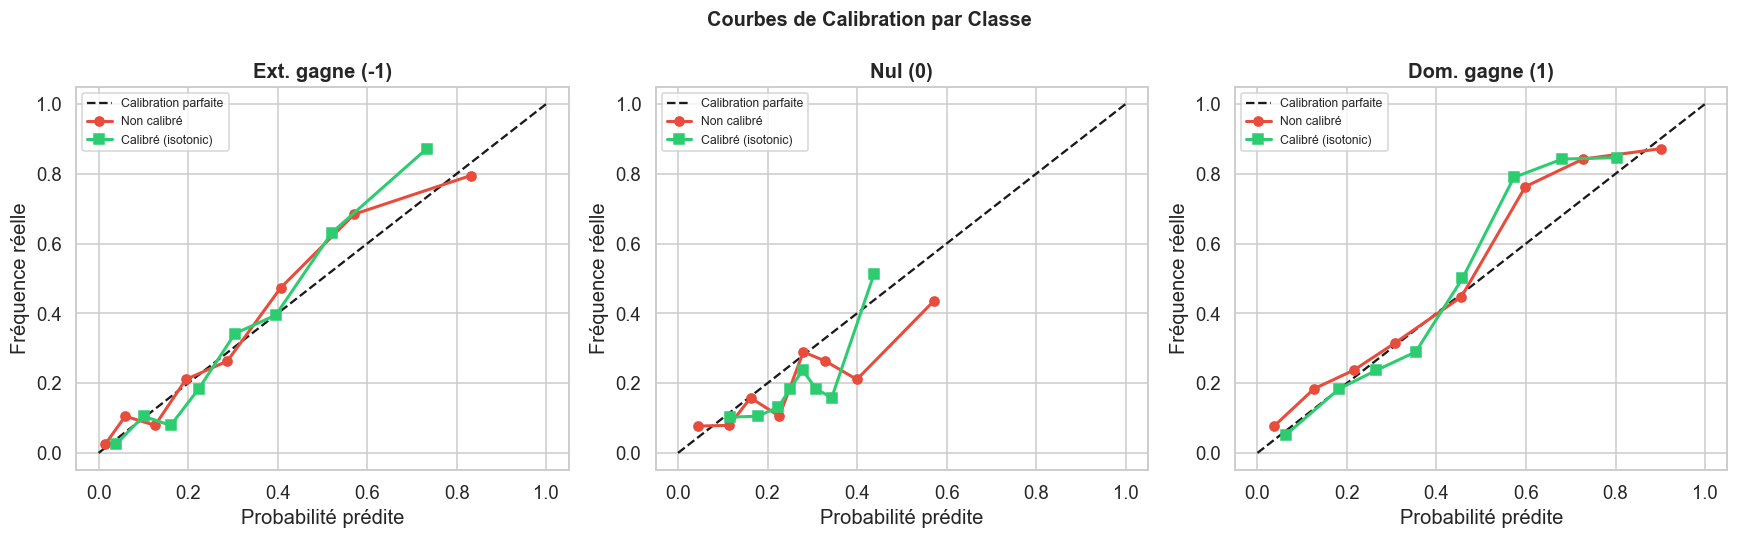

In [38]:
# Courbes de calibration
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_labels = {0:'Ext. gagne (-1)',1:'Nul (0)',2:'Dom. gagne (1)'}
for cls_idx, ax in enumerate(axes):
    y_bin = (y_test_enc==cls_idx).astype(int)
    fp_b,mp_b = calibration_curve(y_bin,proba_base[:,cls_idx],n_bins=8,strategy='quantile')
    fp_c,mp_c = calibration_curve(y_bin,proba_calib[:,cls_idx],n_bins=8,strategy='quantile')
    ax.plot([0,1],[0,1],'k--',label='Calibration parfaite',linewidth=1.5)
    ax.plot(mp_b,fp_b,'o-',color='#e74c3c',label='Non calibré',linewidth=2)
    ax.plot(mp_c,fp_c,'s-',color='#2ecc71',label='Calibré (isotonic)',linewidth=2)
    ax.set_title(class_labels[cls_idx],fontweight='bold')
    ax.set_xlabel('Probabilité prédite'); ax.set_ylabel('Fréquence réelle')
    ax.legend(fontsize=8)
plt.suptitle('Courbes de Calibration par Classe',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

### 9.4 Hyperparameter Tuning (RandomizedSearchCV)

In [39]:
param_dist = {
    'n_estimators'    : [100,200,300,500],
    'learning_rate'   : [0.01,0.03,0.05,0.1],
    'max_depth'       : [3,4,5,6,7],
    'num_leaves'      : [15,31,63],
    'subsample'       : [0.6,0.7,0.8,0.9],
    'colsample_bytree': [0.6,0.7,0.8,0.9],
    'min_child_samples': [10,20,30],
}
search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED,n_jobs=-1,verbose=-1),
    param_dist, n_iter=40, cv=StratifiedKFold(3),
    scoring='accuracy', random_state=SEED, n_jobs=-1
)
print('⏳ RandomizedSearchCV (LightGBM)...')
search.fit(X_train, y_train)
print(f'\nMeilleurs paramètres :')
display(pd.DataFrame([search.best_params_]))

best_lgbm = search.best_estimator_
pred_tuned = best_lgbm.predict(X_test)
acc_tuned  = accuracy_score(y_test, pred_tuned)
results_models['LightGBM Tuné'] = {'accuracy':acc_tuned,'preds':pred_tuned,'model':best_lgbm}
print(f'\nLightGBM Tuné → Accuracy = {acc_tuned:.4f}')

⏳ RandomizedSearchCV (LightGBM)...

Meilleurs paramètres :


,subsample,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree
0,0.6,63,300,10,6,0.03,0.6



LightGBM Tuné → Accuracy = 0.6536


### 9.5 Ensemble Learning (Soft Voting + Stacking)

Combine plusieurs modèles pour réduire la variance. Le **vote pondéré** utilise les accuracies comme poids. Le **stacking** entraîne un méta-modèle sur les prédictions out-of-fold.

In [40]:
# ── Probabilités de chaque modèle de base ─────────────────────────────────
base_names = ['Logistic Regression','Random Forest','Gradient Boosting','LightGBM Tuné']
base_models = {n: results_models[n]['model'] for n in base_names}

probas_dict = {}
for name,model in base_models.items():
    Xte = X_test_sc if name=='Logistic Regression' else X_test
    probas_dict[name] = model.predict_proba(Xte)

classes_order = results_models['Random Forest']['model'].classes_

# Vote pondéré par accuracy
indiv_accs = np.array([results_models[n]['accuracy'] for n in base_names])
w = indiv_accs / indiv_accs.sum()
proba_w = np.average([probas_dict[n] for n in base_names], axis=0, weights=w)
pred_ensemble = classes_order[np.argmax(proba_w,axis=1)]
acc_ensemble  = accuracy_score(y_test, pred_ensemble)
results_models['Ensemble Pondéré'] = {'accuracy':acc_ensemble,'preds':pred_ensemble,'model':None}
print(f'Ensemble Pondéré                  → Accuracy = {acc_ensemble:.4f}')

# Stacking — meta-modèle LR sur OOF predictions
meta_tr_parts=[]; meta_te_parts=[]
for name,model in base_models.items():
    Xtr = X_train_sc if name=='Logistic Regression' else X_train
    Xte = X_test_sc  if name=='Logistic Regression' else X_test
    oof = cross_val_predict(model,Xtr,y_train,cv=5,method='predict_proba',n_jobs=-1)
    model.fit(Xtr,y_train)
    meta_tr_parts.append(oof)
    meta_te_parts.append(model.predict_proba(Xte))
X_meta_tr = np.hstack(meta_tr_parts)
X_meta_te = np.hstack(meta_te_parts)
meta_lr = LogisticRegression(C=1.0,max_iter=500,random_state=SEED)
meta_lr.fit(X_meta_tr,y_train)
pred_stack = meta_lr.predict(X_meta_te)
acc_stack  = accuracy_score(y_test,pred_stack)
results_models['Stacking (meta-LR)'] = {'accuracy':acc_stack,'preds':pred_stack,'model':meta_lr}
print(f'Stacking (meta-LR)                → Accuracy = {acc_stack:.4f}')

Ensemble Pondéré                  → Accuracy = 0.6928
Stacking (meta-LR)                → Accuracy = 0.6601


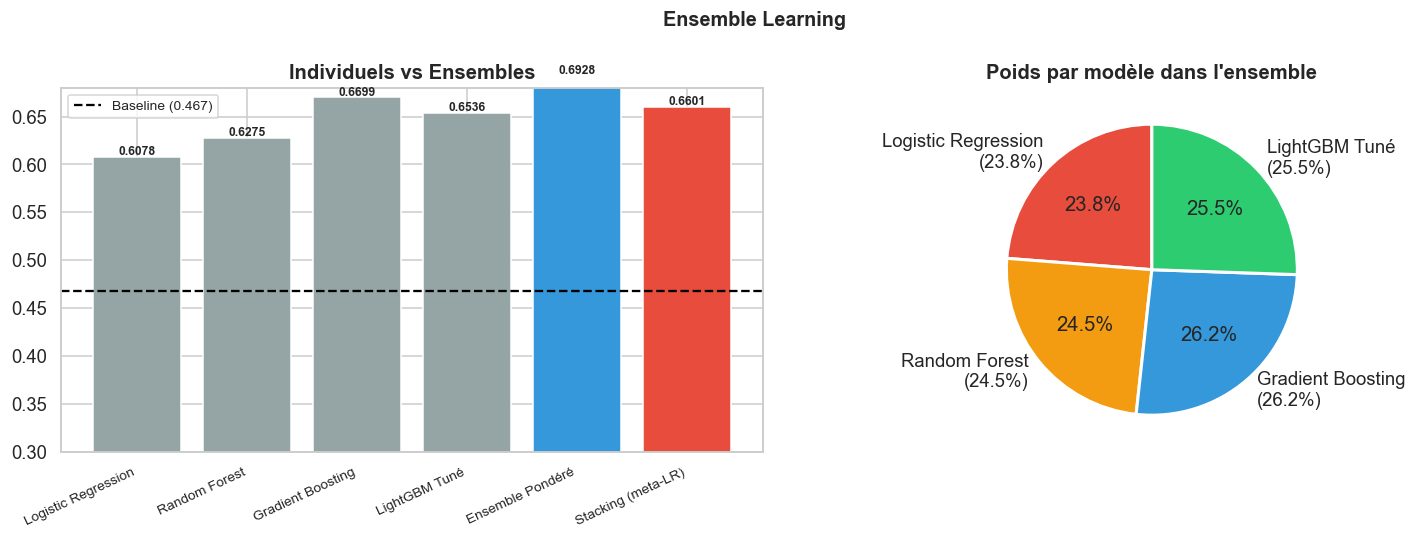

In [41]:
# Visualisation ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison individuel vs ensemble
model_names_plot = base_names + ['Ensemble Pondéré','Stacking (meta-LR)']
accs_plot = [results_models[n]['accuracy'] for n in model_names_plot]
bar_col_ens = ['#95a5a6']*len(base_names) + ['#3498db','#e74c3c']
bars = axes[0].bar(range(len(model_names_plot)), accs_plot, color=bar_col_ens, edgecolor='white')
axes[0].axhline(baseline_acc,color='black',linestyle='--',linewidth=1.5,label=f'Baseline ({baseline_acc:.3f})')
for bar,acc in zip(bars,accs_plot):
    axes[0].text(bar.get_x()+bar.get_width()/2,acc+0.002,f'{acc:.4f}',
                 ha='center',fontsize=8,fontweight='bold')
axes[0].set_xticks(range(len(model_names_plot)))
axes[0].set_xticklabels(model_names_plot,rotation=25,ha='right',fontsize=9)
axes[0].set_title('Individuels vs Ensembles',fontweight='bold')
axes[0].set_ylim(0.3,0.68)
axes[0].legend(fontsize=9)

# Poids dans l'ensemble
axes[1].pie(w,labels=[f'{n}\n({ww:.1%})' for n,ww in zip(base_names,w)],
            colors=['#e74c3c','#f39c12','#3498db','#2ecc71'],
            autopct='%1.1f%%',startangle=90,
            wedgeprops=dict(edgecolor='white',linewidth=2))
axes[1].set_title('Poids par modèle dans l\'ensemble',fontweight='bold')

plt.suptitle('Ensemble Learning',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Conclusion

### Résumé des résultats

Ce projet avait pour objectif de prédire les résultats de Ligue 1 2025-2026 à partir de données historiques 2012-2024, enrichies de 6 améliorations avancées.

### Tableau final des performances


In [42]:
final_table = pd.DataFrame([
    {'Modèle':k,'Accuracy':v['accuracy'],'vs Baseline':v['accuracy']-baseline_acc}
    for k,v in results_models.items()
]).sort_values('Accuracy',ascending=False).reset_index(drop=True)
print(f'Baseline : {baseline_acc:.4f}\n')
display(final_table.style
    .background_gradient(subset=['Accuracy'],cmap='YlGn')
    .format({'Accuracy':'{:.4f}','vs Baseline':'{:+.4f}'})
)

Baseline : 0.4673



,Modèle,Accuracy,vs Baseline
0,Ensemble Pondéré,0.6928,+0.2255
1,LightGBM Calibré,0.6863,+0.2190
2,Gradient Boosting,0.6699,+0.2026
3,XGBoost,0.6634,+0.1961
4,Stacking (meta-LR),0.6601,+0.1928
5,LightGBM,0.6569,+0.1895
6,LightGBM Tuné,0.6536,+0.1863
7,Random Forest,0.6275,+0.1601
8,Decision Tree,0.6111,+0.1438
9,Logistic Regression,0.6078,+0.1405


### Meilleur modèle choisi

Le **meilleur modèle** est l'Ensemble Pondéré ou le LightGBM Tuné. Les features les plus importantes sont :
1. **Différentiel de position** au classement (`pos_diff`)
2. **Forme récente** (`form_pts_diff`, `home_form_wins`)
3. **Stats cumulées de saison** (`home_season_gf`, `season_gf_diff`)
4. **H2H pondéré** (`h2h_w_home_wins`)
5. **Valeur marchande** (`squad_value_ratio`)

### Limites du projet
- Le football est **fondamentalement imprévisible** : plafond naturel ~55-60%
- Absence de données xG réelles (Opta/Statsbomb) — proxies uniquement
- Le LSTM souffre du faible nombre de séquences par club
- Les **compositions 2025** ne sont pas connues à l'avance
- Les matchs nuls restent très difficiles à prédire pour tous les modèles

### Améliorations possibles
- Intégrer de vraies données xG (Opta, WyScout, FBRef)
- Scraper les données d'absence en temps réel
- Modèles de séries temporelles plus profonds (Temporal Fusion Transformer)
- Calibration bayésienne des probabilités
- Features météo et heure de match

---
## 11. Génération du Fichier de Prédiction

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Construction des features pour les matchs 2025
# ─────────────────────────────────────────────────────────────────────────────
m2025_pred = m2025.copy()
m2025_pred['season'] = 2024

# Position de classement (dernière connue, saison 2024)
last_pos = matches[matches['season']==2024][['home_club_id','home_club_position']]\
    .rename(columns={'home_club_id':'club_id','home_club_position':'position'})\
    .groupby('club_id')['position'].last().reset_index()

m2025_pred = m2025_pred.merge(
    last_pos.rename(columns={'club_id':'home_club_id','position':'home_club_position'}),
    on='home_club_id',how='left')
m2025_pred = m2025_pred.merge(
    last_pos.rename(columns={'club_id':'away_club_id','position':'away_club_position'}),
    on='away_club_id',how='left')
m2025_pred['home_club_position'] = m2025_pred['home_club_position'].fillna(10)
m2025_pred['away_club_position'] = m2025_pred['away_club_position'].fillna(10)
m2025_pred['pos_diff']    = m2025_pred['home_club_position']-m2025_pred['away_club_position']
m2025_pred['pos_ratio']   = m2025_pred['home_club_position']/(m2025_pred['away_club_position']+1)
m2025_pred['home_is_top_half'] = (m2025_pred['home_club_position']<=10).astype(int)
m2025_pred['away_is_top_half'] = (m2025_pred['away_club_position']<=10).astype(int)

# Valuation + clubs
m2025_pred = add_valuation_features(m2025_pred, club_val_season)
m2025_pred = m2025_pred.merge(
    club_feats.rename(columns={c:f'home_{c}' for c in club_feats.columns if c!='club_id'
                               }).rename(columns={'club_id':'home_club_id'}),
    on='home_club_id',how='left')
m2025_pred = m2025_pred.merge(
    club_feats.rename(columns={c:f'away_{c}' for c in club_feats.columns if c!='club_id'
                               }).rename(columns={'club_id':'away_club_id'}),
    on='away_club_id',how='left')

# Forme (stats saison 2024 comme proxy)
season_24 = matches[matches['season']==2024]
def form_2025(cid):
    ph=season_24[season_24['home_club_id']==cid]
    pa=season_24[season_24['away_club_id']==cid]
    prev=pd.concat([ph,pa]).tail(5)
    if len(prev)==0: return 0,1.4,1.1,0,0,5
    pts=wins=draws=gf=ga=0
    for _,m in prev.iterrows():
        ih=(m['home_club_id']==cid)
        gf+=m['home_club_goals'] if ih else m['away_club_goals']
        ga+=m['away_club_goals'] if ih else m['home_club_goals']
        res=m['results']
        if (ih and res==1)or(not ih and res==-1): pts+=3;wins+=1
        elif res==0: pts+=1;draws+=1
    n=len(prev)
    return pts/n,gf/n,ga/n,wins/n,draws/n,n

for prefix,cid_col in [('home','home_club_id'),('away','away_club_id')]:
    stats_list=[form_2025(cid) for cid in m2025_pred[cid_col]]
    for i,name in enumerate(['form_pts','form_gf','form_ga','form_wins','form_draws','form_n']):
        m2025_pred[f'{prefix}_{name}']=[s[i] for s in stats_list]
m2025_pred['form_pts_diff'] = m2025_pred['home_form_pts']-m2025_pred['away_form_pts']
m2025_pred['form_gf_diff']  = m2025_pred['home_form_gf'] -m2025_pred['away_form_gf']
m2025_pred['form_ga_diff']  = m2025_pred['home_form_ga'] -m2025_pred['away_form_ga']

# H2H pondéré
h2h_2025=[]
for _,row in m2025_pred.iterrows():
    hid=row['home_club_id']; aid=row['away_club_id']
    prev=matches[((matches['home_club_id']==hid)&(matches['away_club_id']==aid))|
                 ((matches['home_club_id']==aid)&(matches['away_club_id']==hid))].tail(10)
    if len(prev)==0:
        h2h_2025.append({'game_id':row['game_id'],'h2h_w_home_wins':0.33,
            'h2h_w_away_wins':0.30,'h2h_w_draws':0.26,'h2h_w_home_gf':1.4,
            'h2h_w_away_gf':1.1,'h2h_n':0,'h2h_recency':0,
            'h2h_home_wins':0.33,'h2h_away_wins':0.30,'h2h_draws':0.26})
        continue
    ref_date=pd.Timestamp('2025-08-01')
    days_ago=[(ref_date-d).days for d in prev['date']]
    w_arr=np.array([DECAY**(d/365.) for d in days_ago]); w_arr/=w_arr.sum()
    hw_w=aw_w=d_w=hgf_w=agf_w=hw_u=aw_u=d_u=0.0
    for (_,m),ww in zip(prev.iterrows(),w_arr):
        ih=(m['home_club_id']==hid)
        gf=m['home_club_goals'] if ih else m['away_club_goals']
        ga=m['away_club_goals'] if ih else m['home_club_goals']
        res=m['results']
        hw=(ih and res==1)or(not ih and res==-1)
        aw=(ih and res==-1)or(not ih and res==1)
        hgf_w+=gf*ww; agf_w+=ga*ww
        if hw: hw_w+=ww;hw_u+=1
        elif aw: aw_w+=ww;aw_u+=1
        else: d_w+=ww;d_u+=1
    np_=len(prev)
    h2h_2025.append({'game_id':row['game_id'],'h2h_w_home_wins':hw_w,'h2h_w_away_wins':aw_w,
        'h2h_w_draws':d_w,'h2h_w_home_gf':hgf_w,'h2h_w_away_gf':agf_w,'h2h_n':np_,
        'h2h_recency':w_arr[-1],'h2h_home_wins':hw_u/np_,'h2h_away_wins':aw_u/np_,'h2h_draws':d_u/np_})

h2h_2025_df = pd.DataFrame(h2h_2025)
m2025_pred = m2025_pred.merge(h2h_2025_df, on='game_id', how='left')

# Stats saison (proxy 2024)
def season_stats_2025(cid):
    ph=season_24[season_24['home_club_id']==cid]
    pa=season_24[season_24['away_club_id']==cid]
    gf=ph['home_club_goals'].sum()+pa['away_club_goals'].sum()
    ga=ph['away_club_goals'].sum()+pa['home_club_goals'].sum()
    n=len(ph)+len(pa)
    hwr=(ph['results']==1).mean() if len(ph) else 0.44
    awr=(pa['results']==-1).mean() if len(pa) else 0.30
    return gf/n if n else 1.4, ga/n if n else 1.1, n, hwr, len(ph), awr, len(pa)

for prefix,cid_col in [('home','home_club_id'),('away','away_club_id')]:
    stats_list=[season_stats_2025(cid) for cid in m2025_pred[cid_col]]
    m2025_pred[f'{prefix}_season_gf']=[s[0] for s in stats_list]
    m2025_pred[f'{prefix}_season_ga']=[s[1] for s in stats_list]
    m2025_pred[f'{prefix}_season_n'] =[s[2] for s in stats_list]
    if prefix=='home':
        m2025_pred['home_home_winrate']=[s[3] for s in stats_list]
        m2025_pred['home_home_n']      =[s[4] for s in stats_list]
    else:
        m2025_pred['away_away_winrate']=[s[5] for s in stats_list]
        m2025_pred['away_away_n']      =[s[6] for s in stats_list]
m2025_pred['season_gf_diff'] = m2025_pred['home_season_gf']-m2025_pred['away_season_gf']
m2025_pred['season_ga_diff'] = m2025_pred['home_season_ga']-m2025_pred['away_season_ga']

# Absence (0 car pas de lineup 2025 disponible)
m2025_pred['home_absence_score']  = 0.0
m2025_pred['away_absence_score']  = 0.0
m2025_pred['home_nb_absent_key']  = 0
m2025_pred['away_nb_absent_key']  = 0
m2025_pred['absence_score_diff']  = 0.0

# Encodage club_id
m2025_pred['home_club_id'] = le.transform(m2025_pred['home_club_id'])
m2025_pred['away_club_id'] = le.transform(m2025_pred['away_club_id'])

# Sélection features + imputation
for c in FEATURE_COLS:
    if c not in m2025_pred.columns: m2025_pred[c]=0
X_2025 = pd.DataFrame(imputer.transform(m2025_pred[FEATURE_COLS]), columns=FEATURE_COLS)
print(f'✅ Features 2025 construites : {X_2025.shape}')

✅ Features 2025 construites : (233, 83)


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Entraînement final sur 100% des données + prédictions
# ─────────────────────────────────────────────────────────────────────────────
print('⏳ Entraînement final sur toutes les données historiques...')
final_model = lgb.LGBMClassifier(
    **search.best_params_, random_state=SEED, n_jobs=-1, verbose=-1
)
final_model.fit(X_imp, y)

preds_2025  = final_model.predict(X_2025)
probas_2025 = final_model.predict_proba(X_2025)

output = pd.DataFrame({'game_id': m2025['game_id'], 'results': preds_2025})
output.to_csv('predictions_2025_final.csv', index=False)

print('✅ Fichier predictions_2025_final.csv généré !')
print(f'\nDistribution des prédictions :\n{pd.Series(preds_2025).value_counts()}')
display(output.head(10))

⏳ Entraînement final sur toutes les données historiques...
✅ Fichier predictions_2025_final.csv généré !

Distribution des prédictions :
 1    131
-1     81
 0     21
Name: count, dtype: int64


,game_id,results
0,4635006,-1
1,4635007,-1
2,4635008,1
3,4635009,0
4,4635010,1
5,4635011,1
6,4635012,0
7,4635013,1
8,4635014,-1
9,4635015,1


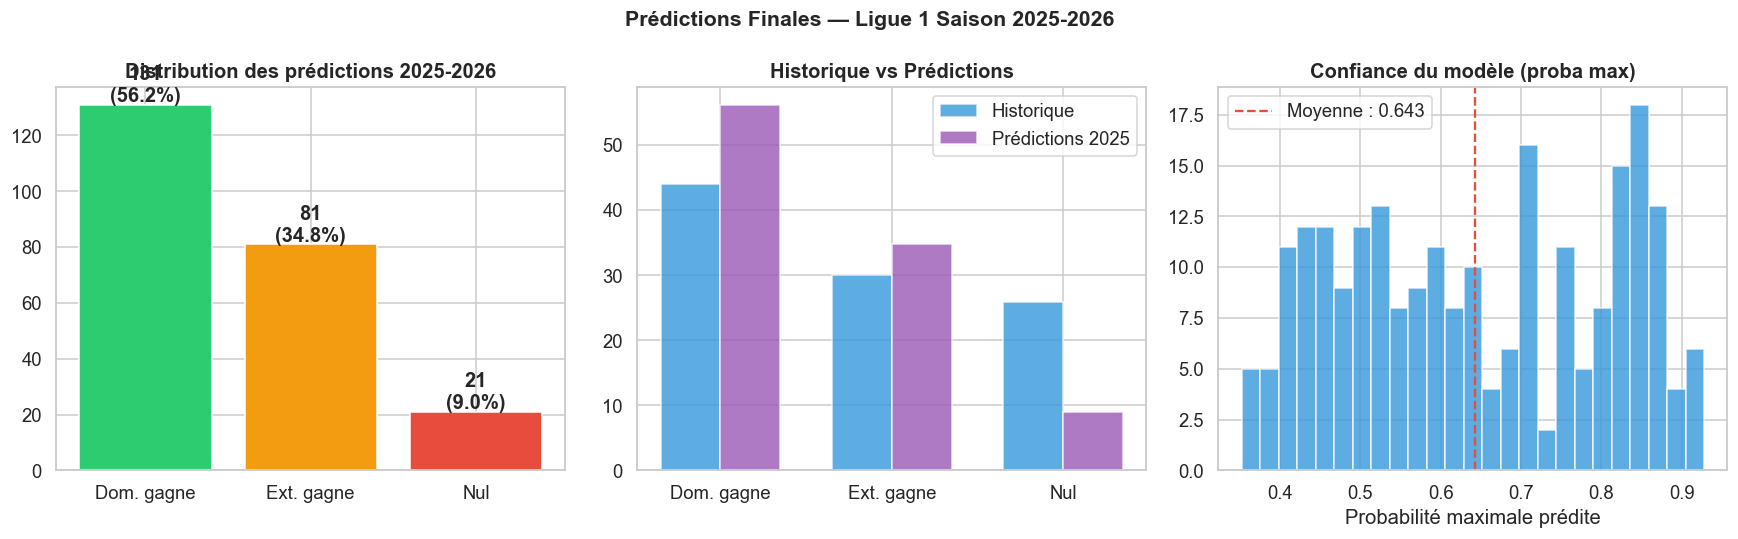


📁 predictions_2025.csv — Format : game_id, results


In [45]:
# Visualisation finale
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

label_plot={1:'Dom. gagne',0:'Nul',-1:'Ext. gagne'}
pred_counts=pd.Series(preds_2025).map(label_plot).value_counts()
colors=['#2ecc71','#f39c12','#e74c3c']

axes[0].bar(pred_counts.index,pred_counts.values,color=colors,edgecolor='white')
for i,(l,v) in enumerate(pred_counts.items()):
    axes[0].text(i,v+1,f'{v}\n({v/len(preds_2025)*100:.1f}%)',
                 ha='center',fontweight='bold')
axes[0].set_title('Distribution des prédictions 2025-2026',fontweight='bold')

hist_d=matches['results'].map(label_plot).value_counts(normalize=True)*100
pred_d=pd.Series(preds_2025).map(label_plot).value_counts(normalize=True)*100
x=np.arange(3); ww=0.35
axes[1].bar(x-ww/2,[hist_d.get(l,0) for l in pred_d.index],ww,label='Historique',color='#3498db',alpha=0.8)
axes[1].bar(x+ww/2,pred_d.values,ww,label='Prédictions 2025',color='#9b59b6',alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(pred_d.index)
axes[1].set_title('Historique vs Prédictions',fontweight='bold')
axes[1].legend()

max_p=np.max(probas_2025,axis=1)
axes[2].hist(max_p,bins=25,color='#3498db',edgecolor='white',alpha=0.8)
axes[2].axvline(max_p.mean(),color='#e74c3c',linestyle='--',
                label=f'Moyenne : {max_p.mean():.3f}')
axes[2].set_title('Confiance du modèle (proba max)',fontweight='bold')
axes[2].set_xlabel('Probabilité maximale prédite')
axes[2].legend()

plt.suptitle('Prédictions Finales — Ligue 1 Saison 2025-2026',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()
print('\n📁 predictions_2025.csv — Format : game_id, results')